<a href="https://colab.research.google.com/github/ambermartin-data-lab/healthfirst-data-analytics-academy-2025-2026/blob/main/Capstone_Project_2026_Healthcare_Claims_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Claims Processing Risk and Accuracy Analysis
### Using Synthetic Medical Claims Data

**Project Overview**

Healthcare organizations must process claims efficiently and accurately to ensure timely reimbursement, reduce administrative burden, and maintain compliance with federal and state regulations. Inefficiencies in claims processing—such as missing documentation, authorization gaps, or claim denials—can lead to delays, increased costs, and operational risk.

Rather than directly measuring timeliness, this analysis identifies claims that are at risk for delays or rework using key operational indicators.

The analysis is performed using a synthetic medical claims dataset from Kaggle, designed to simulate claim outcomes, payer behavior, prior authorization, documentation completeness, and denial codes while avoiding PHI exposure.

**Objective**

The goal of this project is to:

*   Identify claims that are at risk for processing delays or rework
*   Evaluate claim accuracy using denial and quality indicators
*   Analyze key drivers of processing inefficiencies
*   Provide insights that can improve operational performance and compliance

**Business Problem**

In healthcare operations, claims that are incomplete, inaccurate, or improperly authorized can:

*   Delay provider reimbursement
*   Increase administrative workload due to rework
*   Contribute to higher denial rates
*   Indicate weaknesses in upstream claim submission processes

This analysis aims to identify risk patterns and operational inefficiencies that may impact claims processing performance.

**Methodology**

This project uses a structured analytical approach to evaluate claims processing performance using a risk-based model.

The methodology includes:

- Data loading and cleaning to ensure consistency and accuracy  
- Feature engineering to create operational indicators  
- Development of a claims processing risk model using key variables such as prior authorization, documentation completeness, and claim outcome  
- Statistical analysis to identify differences between low-risk and high-risk claims  
- Visualization of risk distribution and key drivers  

This approach focuses on identifying operational inefficiencies and claim quality issues that may contribute to delays and rework.


**Expected Outcome**

The final output will be a Claims Processing Scorecard that summarizes:

*   Percentage of claims at risk for delay or rework
*   Key drivers of processing risk (e.g., prior authorization gaps, documentation completeness)
*   Claim denial patterns and accuracy indicators
*   Overall claims processing performance insights

This scorecard can be used as a model for identifying operational inefficiencies, improving claim quality, and supporting compliance monitoring efforts.

## Data Scope and Analytical Pivot

A true claims timeliness metric requires both a claim submission or receipt date and a claim paid, adjudication, or completion date.

This dataset includes `claim_submission_date`, but it does not include a true paid or adjudication date. The `generation_date` field represents when the synthetic dataset was generated and should not be treated as a claim completion date.

Because of this limitation, the project focuses on a claims processing risk and accuracy. This approach evaluates operational indicators that may contribute to delays, rework, or denial, such as prior authorization gaps, documentation completeness, and claim outcomes.

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

**Data Source Connection**

In [ ]:
# Installing Kaggle
!pip install kagglehub

import kagglehub

# Download dataset
path = kagglehub.dataset_download("nudratabbas/denialiq-120k-medical-claims-x12-denial-codes")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'denialiq-120k-medical-claims-x12-denial-codes' dataset.
Path to dataset files: /kaggle/input/denialiq-120k-medical-claims-x12-denial-codes


In [ ]:
# File preview
import os

os.listdir(path)

['payer_rules (1).csv',
 'data_dictionary.csv',
 'denial_labels.csv',
 'claims_main.csv',
 'llm_finetune (1).jsonl',
 'train_test_split.csv']

**Loading Main Dataset**

In [ ]:
# Loading claims file
df = pd.read_csv(path + '/claims_main.csv')


In [ ]:
# I need to check the total rows and columns to make sure it meets the capstone requirement
df.shape

(120000, 25)

In [ ]:
df.head()

,claim_id,claim_submission_date,claim_year,claim_quarter,payer_type,provider_specialty,place_of_service_code,place_of_service_desc,cpt_code,modifier,...,prior_auth_obtained,prior_auth_number,documentation_completeness,claim_amount_usd,outcome,denial_reason_code,denial_category,dataset_version,synthetic_flag,generation_date
0,e46071e9-0fe0-42d8-ab46-dbb0c48341c4,2022-04-22,2022,Q2,Commercial_PPO,Emergency_Medicine,23,Emergency_Room,99283,NaN,...,NaN,NaN,0.40,656.22,denied,CO-4,coding_error,2.0,True,2026-04-28
1,a641a4ce-38d4-4467-a9d3-d4970735ecc0,2022-07-24,2022,Q3,Medicare_FFS,Internal_Medicine,11,Office,99215,25,...,NaN,NaN,0.37,332.89,denied,CO-97,duplicate,2.0,True,2026-04-28
2,2bd53273-5f36-46ad-b777-0035afd1e2e7,2022-08-24,2022,Q3,Commercial_EPO,Cardiology,2,Telehealth,93000,NaN,...,NaN,NaN,0.65,185.97,denied,CO-4,bundling,2.0,True,2026-04-28
3,72df5380-e03a-4ae9-a1e0-3d3aadf13daf,2021-07-26,2021,Q3,Commercial_PPO,Physical_Therapy,11,Office,97530,59,...,NaN,NaN,0.85,157.25,paid,NaN,NaN,2.0,True,2026-04-28
4,9eb5d58c-3f62-40a9-971f-37855af76d48,2021-12-01,2021,Q4,Medicaid_Managed,Obstetrics_Gynecology,23,Emergency_Room,59400,NaN,...,False,NaN,0.38,8991.46,denied,CO-16,auth_missing,2.0,True,2026-04-28


**Data Loading Progress**

The dataset was imported directly from Kaggle using the kagglehub library. This approach ensures efficient and reproducible access to large-scale claims data.

The dataset contains approximately 120,000 synthetic medical claims, including submission dates, claim outcomes, payer rules, and denial codes.

### Key Findings & Business Impact

The main claims dataset was successfully loaded and reviewed for row and column count.

This confirms that the file contains enough records to support the capstone analysis and allows the project to move forward into data exploration.

From a healthcare compliance perspective, validating the dataset size and structure is important because incomplete or improperly loaded data could lead to inaccurate reporting.

#Exploring the Dataset

Now that the dataset has been loaded, I need to explore the data to determine the best analysis options.

In [ ]:
# Column snapshot
df.columns

Index(['claim_id', 'claim_submission_date', 'claim_year', 'claim_quarter',
       'payer_type', 'provider_specialty', 'place_of_service_code',
       'place_of_service_desc', 'cpt_code', 'modifier', 'primary_icd10_dx',
       'primary_icd10_desc', 'secondary_icd10_dx', 'secondary_dx_count',
       'prior_auth_required', 'prior_auth_obtained', 'prior_auth_number',
       'documentation_completeness', 'claim_amount_usd', 'outcome',
       'denial_reason_code', 'denial_category', 'dataset_version',
       'synthetic_flag', 'generation_date'],
      dtype='object')

In [ ]:
# DataFrame Snapshot
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   claim_id                    120000 non-null  object 
 1   claim_submission_date       120000 non-null  object 
 2   claim_year                  120000 non-null  int64  
 3   claim_quarter               120000 non-null  object 
 4   payer_type                  120000 non-null  object 
 5   provider_specialty          120000 non-null  object 
 6   place_of_service_code       120000 non-null  int64  
 7   place_of_service_desc       120000 non-null  object 
 8   cpt_code                    120000 non-null  object 
 9   modifier                    65753 non-null   object 
 10  primary_icd10_dx            120000 non-null  object 
 11  primary_icd10_desc          120000 non-null  object 
 12  secondary_icd10_dx          84072 non-null   object 
 13  secondary_dx_c


**Data Types Overview**

The dataset contains a mix of categorical, numeric, and boolean data types:

- **object** → Text or categorical data (e.g., claim_id, payer_type, diagnosis codes)  
- **int64** → Integer values (e.g., claim_year, counts)  
- **float64** → Continuous numeric values (e.g., claim_amount_usd, completeness scores)  
- **bool** → Binary indicators (e.g., prior_auth_required, synthetic_flag)  

**Note:**
Date fields such as `claim_submission_date` are currently stored as object type and will be converted to datetime format for trend analysis and data validation.



In [ ]:
# Preview of columns
df.head()

,claim_id,claim_submission_date,claim_year,claim_quarter,payer_type,provider_specialty,place_of_service_code,place_of_service_desc,cpt_code,modifier,...,prior_auth_obtained,prior_auth_number,documentation_completeness,claim_amount_usd,outcome,denial_reason_code,denial_category,dataset_version,synthetic_flag,generation_date
0,e46071e9-0fe0-42d8-ab46-dbb0c48341c4,2022-04-22,2022,Q2,Commercial_PPO,Emergency_Medicine,23,Emergency_Room,99283,NaN,...,NaN,NaN,0.40,656.22,denied,CO-4,coding_error,2.0,True,2026-04-28
1,a641a4ce-38d4-4467-a9d3-d4970735ecc0,2022-07-24,2022,Q3,Medicare_FFS,Internal_Medicine,11,Office,99215,25,...,NaN,NaN,0.37,332.89,denied,CO-97,duplicate,2.0,True,2026-04-28
2,2bd53273-5f36-46ad-b777-0035afd1e2e7,2022-08-24,2022,Q3,Commercial_EPO,Cardiology,2,Telehealth,93000,NaN,...,NaN,NaN,0.65,185.97,denied,CO-4,bundling,2.0,True,2026-04-28
3,72df5380-e03a-4ae9-a1e0-3d3aadf13daf,2021-07-26,2021,Q3,Commercial_PPO,Physical_Therapy,11,Office,97530,59,...,NaN,NaN,0.85,157.25,paid,NaN,NaN,2.0,True,2026-04-28
4,9eb5d58c-3f62-40a9-971f-37855af76d48,2021-12-01,2021,Q4,Medicaid_Managed,Obstetrics_Gynecology,23,Emergency_Room,59400,NaN,...,False,NaN,0.38,8991.46,denied,CO-16,auth_missing,2.0,True,2026-04-28


### Key Findings & Business Impact

The dataset was explored by reviewing column names, data types, and sample records.

This step helped confirm which fields could be used for claims processing, risk classification, denial analysis, and financial review.

Understanding the structure of the dataset ensures that the correct variables are selected for analysis and reduces the risk of using the wrong field in compliance reporting.

## Data Cleaning and Preparation

Before analysis, the dataset needs to be cleaned to ensure consistency and accuracy.

Key steps included:
- Converting date fields to datetime format  
- Handling missing values in key columns  
- Standardizing categorical fields  
- Verifying data types for analysis  

Proper data cleaning ensures that the risk and accuracy metrics are reliable and aligned with business logic.

**Converting Date Columns**

In [ ]:
# Convert date columns to datetime
df['claim_submission_date'] = pd.to_datetime(df['claim_submission_date'])
df['generation_date'] = pd.to_datetime(df['generation_date'], errors='coerce')

**Date Conversion Progress**

Date fields were converted from object format to datetime to support data validation and trend-based analysis. The `generation_date` field is retained for dataset documentation but is not used as a paid or adjudication date.

In [ ]:
# Standardize key fields for claims processing risk analysis

df['outcome'] = df['outcome'].astype(str).str.strip().str.title()
df['denial_category'] = df['denial_category'].fillna('Not Denied')
df['modifier'] = df['modifier'].fillna('None')

df['prior_auth_obtained_clean'] = (
    df['prior_auth_obtained']
    .astype(str)
    .str.strip()
    .str.lower()
)

**Handling Missing Values**

In [ ]:
# Checking missing values
df.isnull().sum()

,0
claim_id,0
claim_submission_date,0
claim_year,0
claim_quarter,0
payer_type,0
provider_specialty,0
place_of_service_code,0
place_of_service_desc,0
cpt_code,0
modifier,0


In [ ]:
# Fill missing prior authorization values
df['prior_auth_obtained'] = df['prior_auth_obtained'].fillna('Unknown')

# Fill missing denial categories
df['denial_category'] = df['denial_category'].fillna('Not Denied')

# Fill missing modifiers
df['modifier'] = df['modifier'].fillna('None')

**Missing Values Progress**

Missing values were addressed by:
- Assigning "Unknown" or "Not Denied" where appropriate  
- Preserving records while maintaining interpretability  

This approach avoids unnecessary data loss while ensuring meaningful analysis.

### Key Findings & Business Impact

**What the analysis shows:**
Date fields were standardized and missing values were reviewed.

**Key insight:**
Consistent formatting allows for accurate time-based calculations.

**Business/Compliance impact:**
Timeliness tracking depends on clean and structured data, which is required for CMS compliance monitoring.

## Feature Engineering

### Transition

After cleaning and preparing the dataset, the next step is to create new fields that make the claims data more useful for analysis.

**Outcome Standardization**

In [ ]:
# Outcome Column
df['outcome'] = df['outcome'].str.strip().str.title()

### Key Findings & Business Impact

Claim outcomes were standardized so that approval and denial results could be analyzed consistently.

This helps reduce confusion caused by inconsistent labels or formatting in the original dataset.

Standardizing outcomes supports accurate denial rate calculations and makes the analysis more reliable for business and compliance review.

**Verifying Data Types**

In [ ]:
df.dtypes

,0
claim_id,object
claim_submission_date,datetime64[ns]
claim_year,int64
claim_quarter,object
payer_type,object
provider_specialty,object
place_of_service_code,int64
place_of_service_desc,object
cpt_code,object
modifier,object


**Data Type Validation**

Data types were reviewed to confirm that:
- Dates are in datetime format  
- Numeric fields are properly formatted  
- Categorical fields are ready for grouping and analysis  

This validation step ensures that all downstream calculations are accurate.

## Analytical Approach: Claims Processing Risk Model

A true claims timeliness metric cannot be directly calculated because the dataset does not include a claim paid, adjudication, or completion date.

Instead of forcing an inaccurate timeliness calculation, this analysis evaluates claims processing risk using available operational indicators.

The claims processing risk model identifies claims that may require additional review, rework, or follow-up based on:

- Prior authorization requirements and gaps
- Documentation completeness
- Claim outcome
- Denial category

This approach reflects real-world claims operations because claims with missing authorization, incomplete documentation, or denial outcomes are more likely to experience processing delays or rework.

**Claims Processing Risk**

In [ ]:
# Create issue flags used to identify claims processing risk

df['prior_auth_missing_issue'] = (
    (df['prior_auth_required'] == True) &
    (df['prior_auth_obtained_clean'].isin(['false', 'no', 'unknown', 'nan', 'none']))
)

df['documentation_issue'] = df['documentation_completeness'] < 0.80

df['denial_issue'] = df['outcome'] == 'Denied'

df['timely_filing_issue'] = (
    df['denial_category']
    .astype(str)
    .str.lower()
    .eq('timely_filing')
)

# Create final risk classification

df['claims_processing_risk'] = np.where(
    df['prior_auth_missing_issue'] |
    df['documentation_issue'] |
    df['denial_issue'] |
    df['timely_filing_issue'],
    'At Risk for Delay or Rework',
    'Lower Risk'
)

df[
    [
        'prior_auth_required',
        'prior_auth_obtained',
        'documentation_completeness',
        'outcome',
        'denial_category',
        'claims_processing_risk'
    ]
].head()

,prior_auth_required,prior_auth_obtained,documentation_completeness,outcome,denial_category,claims_processing_risk
0,False,Unknown,0.40,Denied,coding_error,At Risk for Delay or Rework
1,False,Unknown,0.37,Denied,duplicate,At Risk for Delay or Rework
2,False,Unknown,0.65,Denied,bundling,At Risk for Delay or Rework
3,False,Unknown,0.85,Paid,Not Denied,Lower Risk
4,True,False,0.38,Denied,auth_missing,At Risk for Delay or Rework


### Key Findings & Business Impact

A claims processing risk indicator was created to classify claims based on potential delay or rework risk.

The results help separate claims that appear more operationally stable from claims that may require closer review.

This mirrors real-world scorecard logic because healthcare organizations need to identify claims that may create compliance, operational, or financial risk.

## Accuracy Metric: Denial Rates

Claims accuracy is typically measured by denial rates and adjustment indicators. A high denial rate suggests issues with documentation, coding, or adherence to payer guidelines. This section will analyze the `outcome` and `denial_category` fields to quantify claims accuracy.

Key metrics include:
-   Overall denial rate
-   Denial rates by category

In [ ]:
# Calculate overall denial rate
total_claims = len(df)
denied_claims = df[df['outcome'] == 'Denied'].shape[0]
denial_rate = (denied_claims / total_claims) * 100

print(f"Overall Denial Rate: {denial_rate:.2f}%")

# Display denial rates by category
denial_category_counts = df['denial_category'].value_counts(normalize=True) * 100
print("\nDenial Rates by Category:")
display(denial_category_counts)

Overall Denial Rate: 28.05%

Denial Rates by Category:


,proportion
denial_category,
Not Denied,71.946667
medical_necessity,7.870000
coding_error,6.120000
auth_missing,5.116667
eligibility,3.403333
duplicate,2.204167
timely_filing,1.929167
bundling,1.410000


### Key Findings & Business Impact

The denial rate was calculated to measure the percentage of claims that resulted in a denied outcome.

This metric helps evaluate claims accuracy and identify whether a meaningful portion of claims are failing adjudication.

From a business perspective, denial monitoring is important because high denial rates can create rework, payment delays, provider abrasion, and financial loss.

## Statistical Analysis

This section compares key numeric indicators across claims processing risk categories. The goal is to understand whether claims classified as higher risk differ from lower-risk claims in documentation completeness and claim amount.

### Transition

After calculating processing time, the next step is to segment claims into risk categories.

In [ ]:
# Descriptive statistics for key numeric fields
df[['documentation_completeness', 'claim_amount_usd']].describe()

,documentation_completeness,claim_amount_usd
count,120000.000000,120000.000000
mean,0.724929,2223.581352
std,0.200389,4089.863423
min,0.200000,52.240000
25%,0.580000,242.730000
50%,0.780000,433.270000
75%,0.880000,2556.855000
max,1.000000,37918.580000


In [ ]:
# Compare averages by claims processing risk group
df.groupby('claims_processing_risk')[[
    'documentation_completeness',
    'claim_amount_usd'
]].mean()

,documentation_completeness,claim_amount_usd
claims_processing_risk,,
At Risk for Delay or Rework,0.579831,2223.240365
Lower Risk,0.892176,2223.974393


### Key Findings & Business Impact

Descriptive statistics were used to summarize key numerical fields and compare claim averages by processing risk group.

This helps identify differences in cost, processing behavior, and operational trends across claim categories.

Statistical analysis supports stronger decision-making because it turns raw claim records into measurable patterns.

##Visualizations:

##Claims Processing Risk Distribution

The chart below shows the number of claims classified as lower risk compared to claims at risk for delay or rework.

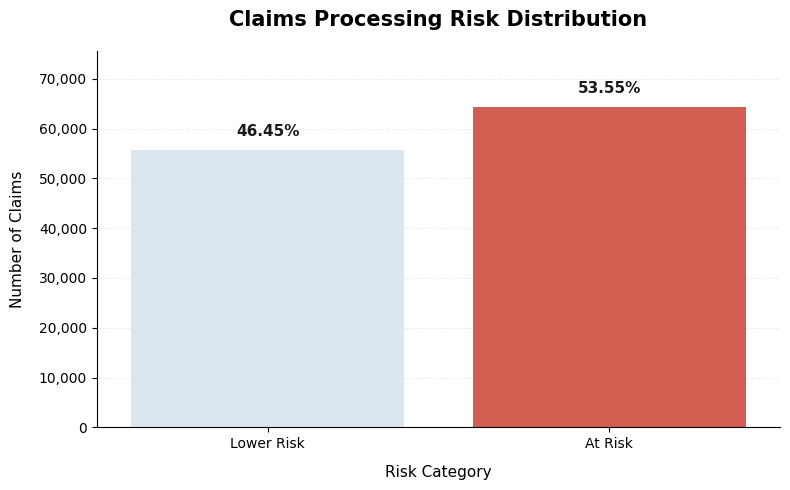

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import kagglehub

# --- Code added to ensure 'df' and 'claims_processing_risk' are defined --- #
# This section is included to resolve `NameError: name 'df' is not defined`
# if preceding data loading and preprocessing cells have not been executed.

# Attempt to define 'path' if not already in the environment
if 'path' not in locals():
    # This will download the dataset if the path is not available, which might re-run work
    # if previous cells were partially executed. For robust self-containment, it's necessary.
    path = kagglehub.dataset_download("nudratabbas/denialiq-120k-medical-claims-x12-denial-codes")

# Load df and perform necessary preprocessing if df is not already defined
if 'df' not in locals():
    df = pd.read_csv(path + '/claims_main.csv')

    # Data Cleaning and Preparation (from previous cells)
    df['claim_submission_date'] = pd.to_datetime(df['claim_submission_date'])
    df['generation_date'] = pd.to_datetime(df['generation_date'], errors='coerce')

    df['outcome'] = df['outcome'].astype(str).str.strip().str.title()
    df['denial_category'] = df['denial_category'].fillna('Not Denied')
    df['modifier'] = df['modifier'].fillna('None')

    df['prior_auth_obtained_clean'] = (
        df['prior_auth_obtained']
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df['prior_auth_obtained'] = df['prior_auth_obtained'].fillna('Unknown')
    df['denial_category'] = df['denial_category'].fillna('Not Denied')
    df['modifier'] = df['modifier'].fillna('None')

    # Claims Processing Risk Model (from previous cells)
    df['prior_auth_missing_issue'] = (
        (df['prior_auth_required'] == True) &
        (df['prior_auth_obtained_clean'].isin(['false', 'no', 'unknown', 'nan', 'none']))
    )
    df['documentation_issue'] = df['documentation_completeness'] < 0.80
    df['denial_issue'] = df['outcome'] == 'Denied'
    df['timely_filing_issue'] = (
        df['denial_category']
        .astype(str)
        .str.lower()
        .eq('timely_filing')
    )
    df['claims_processing_risk'] = np.where(
        df['prior_auth_missing_issue'] |
        df['documentation_issue'] |
        df['denial_issue'] |
        df['timely_filing_issue'],
        'At Risk for Delay or Rework',
        'Lower Risk'
    )
# --- End of added code --- #

# Clean display labels without changing original data
plot_df = df.copy()
plot_df['risk_display'] = plot_df['claims_processing_risk'].replace({
    'At Risk for Delay or Rework': 'At Risk',
    'Lower Risk': 'Lower Risk'
})

order = ['Lower Risk', 'At Risk']

# Healthcare / executive palette
palette = {
    'At Risk': '#E74C3C',      # deep healthcare navy
    'Lower Risk': '#D9E6F2'    # soft blue-gray
}

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=plot_df,
    x='risk_display',
    order=order,
    palette=palette,
    hue='risk_display',
    legend=False
)

# Title and labels
ax.set_title(
    "Claims Processing Risk Distribution",
    fontsize=15,
    fontweight='bold',
    pad=18
)

ax.set_xlabel("Risk Category", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Claims", fontsize=11, labelpad=10)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add percentage labels
total = len(plot_df)

for p in ax.patches:
    count = int(p.get_height())
    percent = count / total * 100

    ax.annotate(
        f"{percent:.2f}%",
        xy=(p.get_x() + p.get_width() / 2, count),
        xytext=(0, 8),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#1A1A1A'
    )

# Clean executive formatting
ax.grid(axis='y', linestyle='--', alpha=0.18)
ax.set_axisbelow(True)
sns.despine(left=False, bottom=False)

# Add space above bars so labels do not touch title
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.show()

## Lower Risk Population Overview

<div style="background-color: #F0F9F0; border-left: 6px solid #2ECC71; padding: 15px; margin-bottom: 20px;">
  <h3 style="color: #2ECC71; margin-top: 0; font-weight: bold;">✅ Understanding the Lower Risk Claims</h3>
  <p style="font-size: 16px; line-height: 1.5;">
    The lower risk population comprises claims that are free from the identified processing issues. These claims demonstrate strong operational characteristics, making them less likely to experience delays or require rework.
  </p>
  <ul style="font-size: 16px; line-height: 1.5; padding-left: 20px;">
    <li><b>Total Lower Risk Claims:</b> 55,745 (46.45%)</li>
    <li><b>No Prior Authorization Issues:</b> Prior authorizations were either not required or successfully obtained.</li>
    <li><b>Complete Documentation:</b> Documentation completeness scores are consistently at 80% or higher.</li>
    <li><b>No Denial Outcomes:</b> These claims have not resulted in a denied outcome.</li>
    <li><b>No Timely Filing Issues:</b> Claims do not exhibit timely filing issues.</li>
  </ul>
  <p style="font-size: 16px; line-height: 1.5;">
    This segment represents efficient claims processing, serving as a benchmark for operational excellence.
  </p>
</div>

### Understanding Issues in 'Lower Risk' Claims

As previously defined, claims classified as 'Lower Risk' are explicitly those that *do not* exhibit any of the identified processing issues (prior authorization gaps, incomplete documentation, denial outcomes, or timely filing issues). Therefore, by definition, an analysis of root causes *within* this 'Lower Risk' population should show zero occurrences of these specific issues.

In [ ]:
lower_risk_claims_df = df[df['claims_processing_risk'] == 'Lower Risk']

# Check the issue flags for the lower risk claims
issue_counts_for_lower_risk = pd.DataFrame({
    'Issue': [
        'Incomplete Documentation',
        'Denied Claim',
        'Missing Prior Authorization',
        'Timely Filing Denial'
    ],
    'Claim Count': [
        lower_risk_claims_df['documentation_issue'].sum(),
        lower_risk_claims_df['denial_issue'].sum(),
        lower_risk_claims_df['prior_auth_missing_issue'].sum(),
        lower_risk_claims_df['timely_filing_issue'].sum()
    ]
})

print("Issue Counts for Lower Risk Claims:")
display(issue_counts_for_lower_risk)

Issue Counts for Lower Risk Claims:


,Issue,Claim Count
0,Incomplete Documentation,0
1,Denied Claim,0
2,Missing Prior Authorization,0
3,Timely Filing Denial,0


### Total Lower Risk Claims vs. Documentation Issues by Payer Type

This chart visualizes the breakdown of 'Lower Risk' claims, showing the total number of claims for each `payer_type` and highlighting the proportion that still have 'Documentation Issues' within this low-risk group. This helps in understanding which payer types contribute to lower risk, and within those, where documentation might still be a minor challenge.

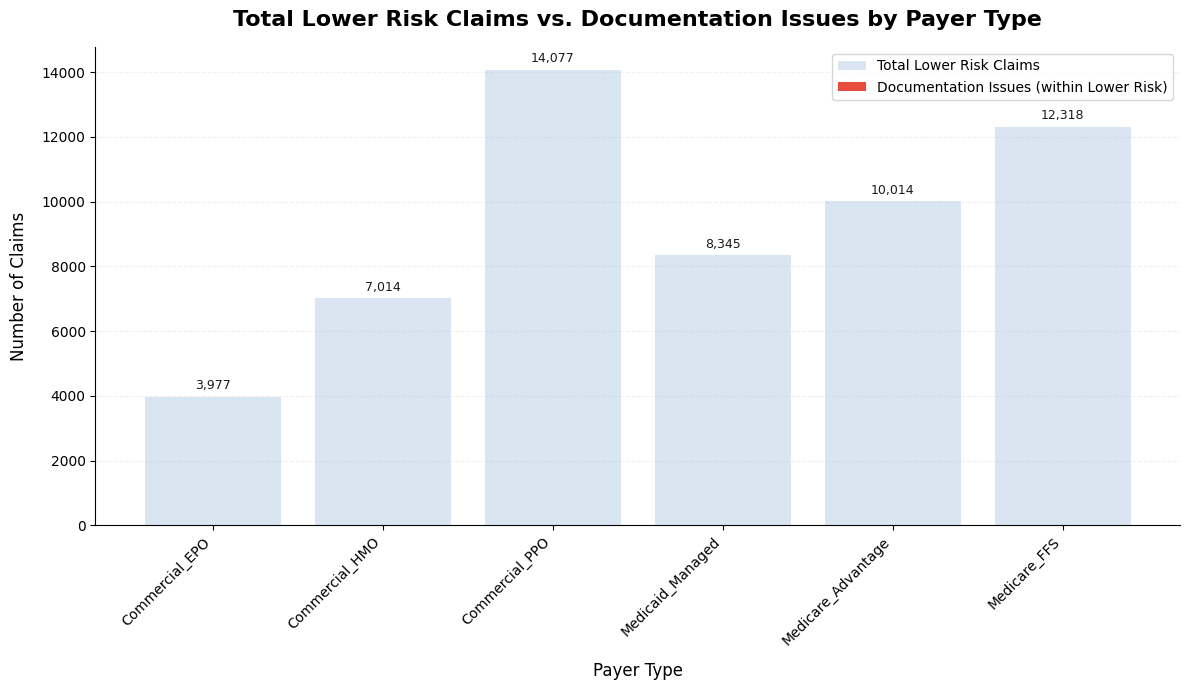

In [ ]:
# Filter for 'Lower Risk' claims
lower_risk_df_filtered = df[df['claims_processing_risk'] == 'Lower Risk']

# Group by payer_type and aggregate
lob_summary_lower_risk = (
    lower_risk_df_filtered.groupby('payer_type')
      .agg(
          Total_Claims=('claim_id','count'),
          Documentation_Issues=('documentation_issue','sum')
      )
      .reset_index()
)

plt.figure(figsize=(12, 7))

# Create the stacked bar chart
p1 = plt.bar(
    lob_summary_lower_risk['payer_type'],
    lob_summary_lower_risk['Total_Claims'],
    color='#D9E6F2',
    edgecolor='none',
    label='Total Lower Risk Claims'
)
p2 = plt.bar(
    lob_summary_lower_risk['payer_type'],
    lob_summary_lower_risk['Documentation_Issues'],
    color='#E74C3C',
    edgecolor='none',
    label='Documentation Issues (within Lower Risk)'
)

plt.title('Total Lower Risk Claims vs. Documentation Issues by Payer Type', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Payer Type', fontsize=12, labelpad=10)
plt.ylabel('Number of Claims', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=10)

# Add count labels for total claims (if not zero)
for bar in p1:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f'{int(height):,}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            color='#1A1A1A'
        )

# Add count labels for documentation issues (if not zero)
for bar in p2:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f'{int(height):,}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, -10),
            textcoords="offset points",
            ha='center',
            va='top',
            fontsize=9,
            color='white'
        )

plt.grid(axis='y', linestyle='--', alpha=0.18)
plt.legend(fontsize=10)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

### High-Risk Claim Drivers: Issue Ranking Analysis

This chart visualizes the primary issues driving claims into the 'At Risk for Delay or Rework' category. It highlights the most frequent problems that contribute to processing inefficiencies and potential delays.

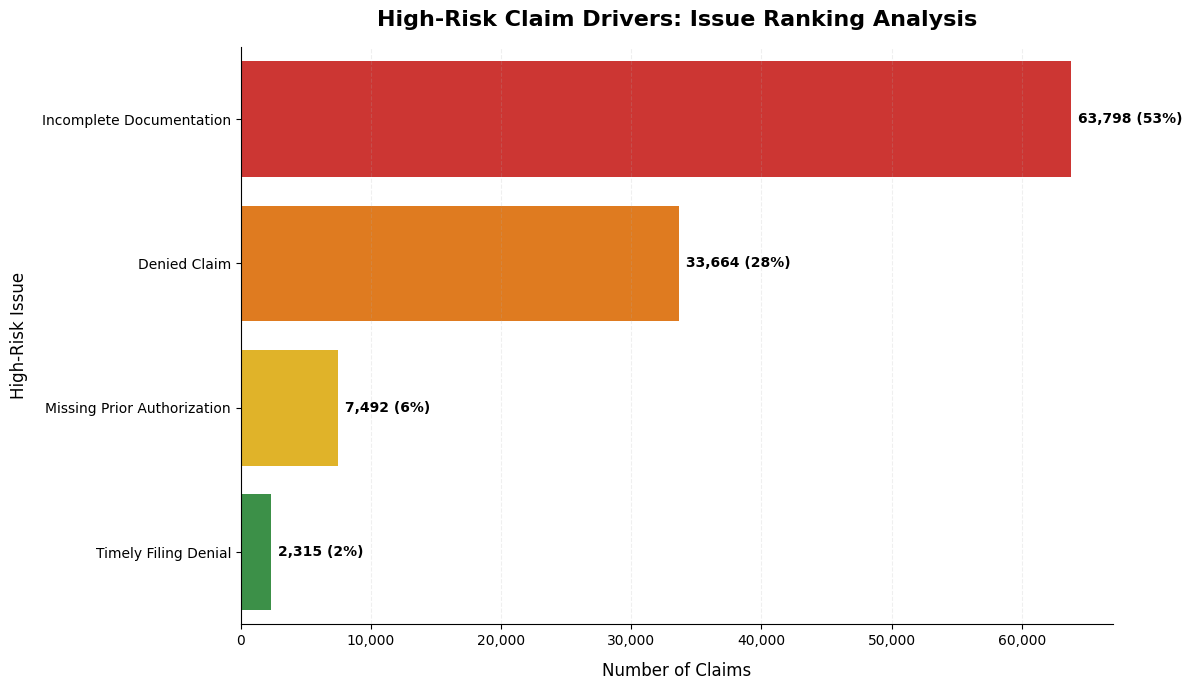

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Assuming issue_summary is already calculated and available from previous steps
issue_summary = pd.DataFrame({
    'Issue': [
        'Incomplete Documentation',
        'Denied Claim',
        'Missing Prior Authorization',
        'Timely Filing Denial'
    ],
    'Claim Count': [
        df['documentation_issue'].sum(),
        df['denial_issue'].sum(),
        df['prior_auth_missing_issue'].sum(),
        df['timely_filing_issue'].sum()
    ]
})

issue_summary['Percent of Total Claims'] = (
    issue_summary['Claim Count'] / len(df) * 100
).round(2)

issue_summary = (
    issue_summary
    .sort_values(by='Claim Count', ascending=False)
    .reset_index(drop=True)
)

issue_summary['Rank'] = issue_summary.index + 1

issue_summary = issue_summary[
    ['Rank', 'Issue', 'Claim Count', 'Percent of Total Claims']
]

# Match executive dashboard color palette, prioritizing red for highest risk
severity_colors = [
    "#E51D1A",  # Red for Incomplete Documentation
    "#FF7A00",  # Orange for Denied Claim
    "#FFC20A",  # Yellow for Missing Prior Authorization
    "#2E9E3E"   # Green for Timely Filing Issue (if applicable, though still an issue)
]

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=issue_summary,
    x="Claim Count",
    y="Issue",
    hue="Issue",
    palette=severity_colors[:len(issue_summary)], # Apply colors based on number of issues
    legend=False
)

ax.set_title(
    "High-Risk Claim Drivers: Issue Ranking Analysis",
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel("Number of Claims", fontsize=12, labelpad=10)
ax.set_ylabel("High-Risk Issue", fontsize=12, labelpad=10)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add count and percentage labels to the bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    percent = issue_summary.loc[i, 'Percent of Total Claims']

    ax.annotate(
        f'{int(width):,} ({percent:.0f}%)',
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.grid(axis='x', linestyle='--', alpha=0.2)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

### Issue Ranking Analysis for Lower Risk Claims

This chart visualizes the issue counts specifically for claims classified as 'Lower Risk'. As previously established, these claims are defined by the absence of the identified processing issues.

### Issue Ranking Analysis for At Risk Claims

This chart presents the issue counts for claims categorized as 'At Risk for Delay or Rework', highlighting the specific problems that contribute to their higher risk classification. These are the issues that drive claims into the high-risk category.

### Total Claims Distribution by Risk Category

This chart provides a holistic view of the entire claims population, segmented into 'Lower Risk' and 'At Risk for Delay or Rework' categories. It allows for a quick understanding of the overall risk profile of the claims submitted.

### Summary of Claims by Risk Category

Here is a numerical summary of the claims distributed across the 'Lower Risk' and 'At Risk for Delay or Rework' categories, along with the total number of claims.

In [ ]:
total_claims = len(df)
lower_risk_claims = df[df['claims_processing_risk'] == 'Lower Risk'].shape[0]
at_risk_claims = df[df['claims_processing_risk'] == 'At Risk for Delay or Rework'].shape[0]

summary_df = pd.DataFrame({
    'Category': ['Total Claims', 'Lower Risk Claims', 'At Risk for Delay or Rework Claims'],
    'Count': [total_claims, lower_risk_claims, at_risk_claims],
    'Percentage': [
        (total_claims / total_claims) * 100,
        (lower_risk_claims / total_claims) * 100,
        (at_risk_claims / total_claims) * 100
    ]
})

summary_df['Count'] = summary_df['Count'].apply(lambda x: f'{x:,}')
summary_df['Percentage'] = summary_df['Percentage'].apply(lambda x: f'{x:.2f}%')

display(summary_df)

,Category,Count,Percentage
0,Total Claims,"120,000",100.00%
1,Lower Risk Claims,"55,745",46.45%
2,At Risk for Delay or Rework Claims,"64,255",53.55%


### Key Findings & Business Impact

The claims processing risk distribution visual shows how claims are spread across the risk categories.

This makes it easier to see whether most claims are low risk or whether a meaningful portion may require additional monitoring.

Visualizing risk distribution helps leadership quickly understand operational exposure without reviewing every individual claim.

## Claim Amount by Risk Category

This visualization compares the distribution of claim amounts between lower-risk claims and claims classified as at risk for delay or rework.

Understanding how claim value varies by risk category helps identify potential financial exposure associated with higher-risk claims.

/tmp/ipykernel_4273/3309541828.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


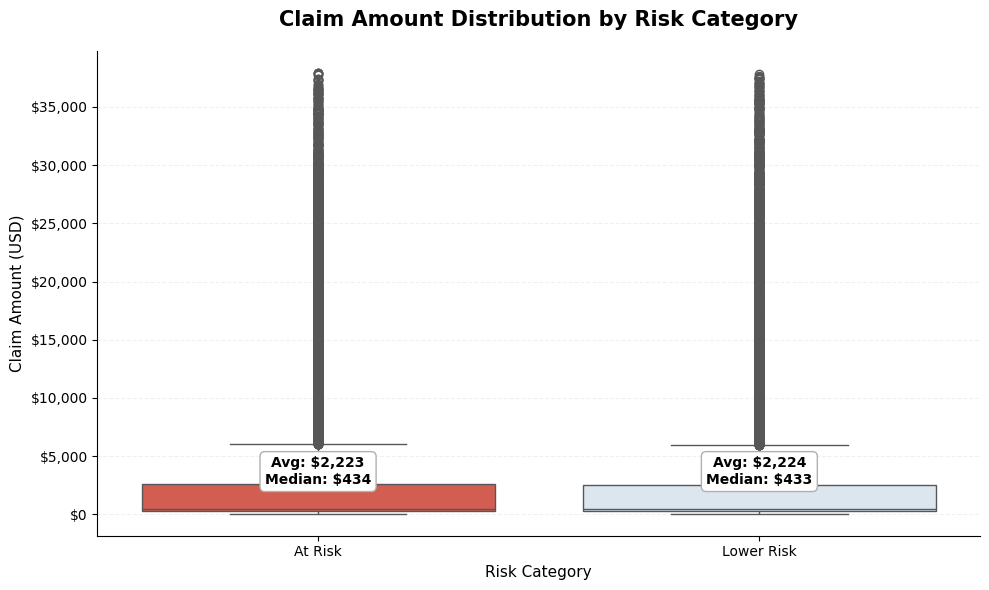

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plot_df = df.copy()
plot_df['risk_display'] = plot_df['claims_processing_risk'].replace({
    'At Risk for Delay or Rework': 'At Risk',
    'Lower Risk': 'Lower Risk'
})

order = ['At Risk', 'Lower Risk']

palette = {
    'At Risk': '#E74C3C',
    'Lower Risk': '#D9E6F2'
}

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=plot_df,
    x='risk_display',
    y='claim_amount_usd',
    order=order,
    palette=palette
)

ax.set_title("Claim Amount Distribution by Risk Category", fontsize=15, fontweight='bold', pad=18)
ax.set_xlabel("Risk Category", fontsize=11)
ax.set_ylabel("Claim Amount (USD)", fontsize=11)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${int(x):,}')
)

# Add average and median labels
for i, category in enumerate(order):
    subset = plot_df[plot_df['risk_display'] == category]['claim_amount_usd']
    avg = subset.mean()
    median = subset.median()

    ax.text(
        i,
        avg + 150,
        f"Avg: ${avg:,.0f}\nMedian: ${median:,.0f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='#B0B0B0', boxstyle='round,pad=0.35')
    )

ax.grid(axis='y', linestyle='--', alpha=0.18)
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('claims_processing_risk')['claim_amount_usd'].mean()

,claim_amount_usd
claims_processing_risk,
At Risk for Delay or Rework,2223.240365
Lower Risk,2223.974393


### Claim Amount Insight, Key Findings & Business Impact

The claim amount analysis shows how average claim dollars differ across processing risk categories.

If higher-risk claims have larger claim amounts, this may indicate greater financial exposure when those claims are delayed, denied, or require rework.

This insight is important because high-dollar claims should be monitored closely to protect financial performance and support accurate claims processing.

##Top Denial Categories

The chart below shows the most common denial categories in the dataset. This supports the accuracy portion of the scorecard by identifying common reasons claims may not be approved.

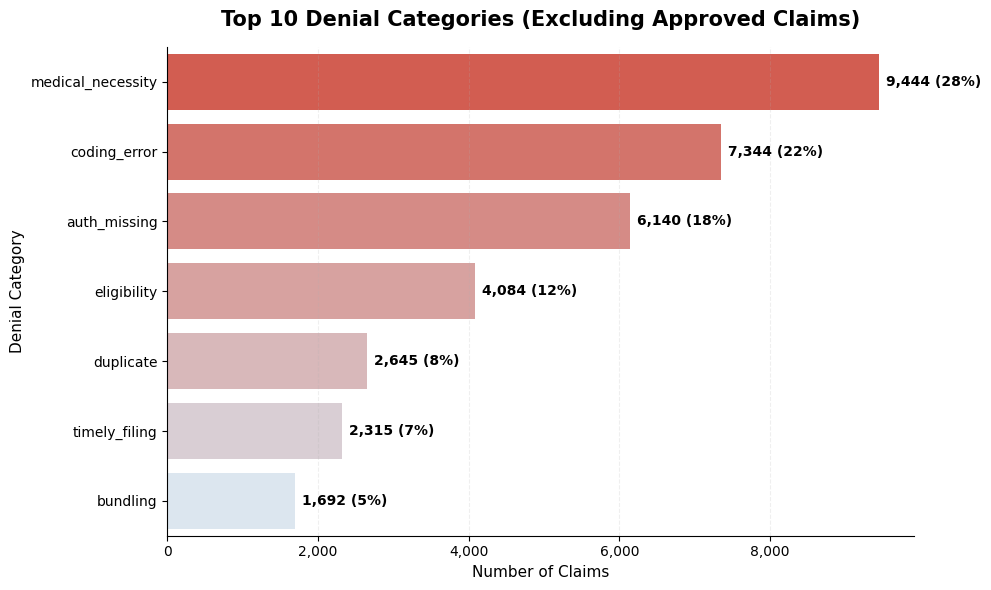

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Filter only true denials
denials_only = df[df['denial_category'] != 'Not Denied']

# Top 10 denial categories
top_denials = denials_only['denial_category'].value_counts().head(10)

# Convert to DataFrame for cleaner plotting
top_denials_df = top_denials.reset_index()
top_denials_df.columns = ['Denial Category', 'Count']

# Total for percentage calculation
total_denials = top_denials_df['Count'].sum()

plt.figure(figsize=(10,6))

# Define the custom bright red color and the target light blue/grey color
start_color = '#E74C3C'
end_color = '#D9E6F2'

# Get the number of categories for the palette
num_categories = len(top_denials_df)

# Generate a palette blending from bright red to light blue/grey
colors = sns.blend_palette([start_color, end_color], n_colors=num_categories)

ax = sns.barplot(
    data=top_denials_df,
    x='Count',
    y='Denial Category',
    palette=colors,
    hue='Denial Category',
    legend=False
)

# Title and labels
ax.set_title(
    "Top 10 Denial Categories (Excluding Approved Claims)",
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel("Number of Claims", fontsize=11)
ax.set_ylabel("Denial Category", fontsize=11)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add count + percentage labels
for i, row in top_denials_df.iterrows():
    count = row['Count']
    pct = (count / total_denials) * 100

    ax.text(
        count + max(top_denials_df['Count']) * 0.01,
        i,
        f'{count:,} ({pct:.0f}%)',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Clean formatting
ax.grid(axis='x', linestyle='--', alpha=0.2)
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
denial_rate = (df['outcome'] == 'Denied').mean() * 100
denial_rate

np.float64(28.053333333333335)

### Denial Category Insight, Key Findings & Business Impact

The denial category analysis reviews only true denied claims and identifies the most common reasons for denial.

This is different from simply counting all claims labeled as denied. The purpose is to understand the denial categories driving claim failures.

Identifying top denial categories helps the organization target root causes such as missing documentation, eligibility issues, coding problems, or authorization gaps.

## Key Risk Drivers Analysis

This section analyzes how key operational variables differ between claims classified as lower risk and those at risk for delay or rework.

In [ ]:
df.groupby('claims_processing_risk')[[
    'prior_auth_required',
    'documentation_completeness'
]].mean()

,prior_auth_required,documentation_completeness
claims_processing_risk,,
At Risk for Delay or Rework,0.455638,0.579831
Lower Risk,0.446587,0.892176


In [ ]:
drivers = {
    'Missing Prior Authorization': 'prior_auth_missing_issue',
    'Incomplete Documentation': 'documentation_issue',
    'Timely Filing Issue': 'timely_filing_issue'
}

driver_impact = []

overall_denial_rate = (df['outcome'] == 'Denied').mean()

for issue_name, column in drivers.items():
    denial_rate_with_issue = df.loc[df[column] == True, 'outcome'].eq('Denied').mean()
    denial_rate_without_issue = df.loc[df[column] == False, 'outcome'].eq('Denied').mean()

    driver_impact.append({
        'Issue Driver': issue_name,
        'Claims With Issue': df[column].sum(),
        'Denial Rate With Issue': round(denial_rate_with_issue * 100, 2),
        'Denial Rate Without Issue': round(denial_rate_without_issue * 100, 2),
        'Lift vs Overall Denial Rate': round((denial_rate_with_issue / overall_denial_rate), 2)
    })

driver_impact_df = pd.DataFrame(driver_impact).sort_values(
    by='Lift vs Overall Denial Rate',
    ascending=False
)

driver_impact_df

,Issue Driver,Claims With Issue,Denial Rate With Issue,Denial Rate Without Issue,Lift vs Overall Denial Rate
2,Timely Filing Issue,2315,100.00,26.64,3.56
0,Missing Prior Authorization,7492,70.88,25.20,2.53
1,Incomplete Documentation,63798,52.77,0.00,1.88


### Key Findings & Business Impact

The key risk drivers analysis compares documentation completeness, prior authorization, provider risk, and other operational factors across claim risk groups.

Claims classified as "At Risk for Delay or Rework" tend to show weaker documentation completeness and higher indicators of operational complexity.

This matters because identifying risk drivers helps organizations focus process improvements on the factors most likely to cause delays, rework, or compliance concerns.

In [ ]:
# Root Cause / Issue Ranking Analysis

issue_summary = pd.DataFrame({
    'Issue': [
        'Incomplete Documentation',
        'Denied Claim',
        'Missing Prior Authorization',
        'Timely Filing Denial'
    ],
    'Claim Count': [
        df['documentation_issue'].sum(),
        df['denial_issue'].sum(),
        df['prior_auth_missing_issue'].sum(),
        df['timely_filing_issue'].sum()
    ]
})

issue_summary['Percent of Total Claims'] = (
    issue_summary['Claim Count'] / len(df) * 100
).round(2)

issue_summary = (
    issue_summary
    .sort_values(by='Claim Count', ascending=False)
    .reset_index(drop=True)
)

issue_summary['Rank'] = issue_summary.index + 1

issue_summary = issue_summary[
    ['Rank', 'Issue', 'Claim Count', 'Percent of Total Claims']
]

issue_summary

,Rank,Issue,Claim Count,Percent of Total Claims
0,1,Incomplete Documentation,63798,53.16
1,2,Denied Claim,33664,28.05
2,3,Missing Prior Authorization,7492,6.24
3,4,Timely Filing Denial,2315,1.93


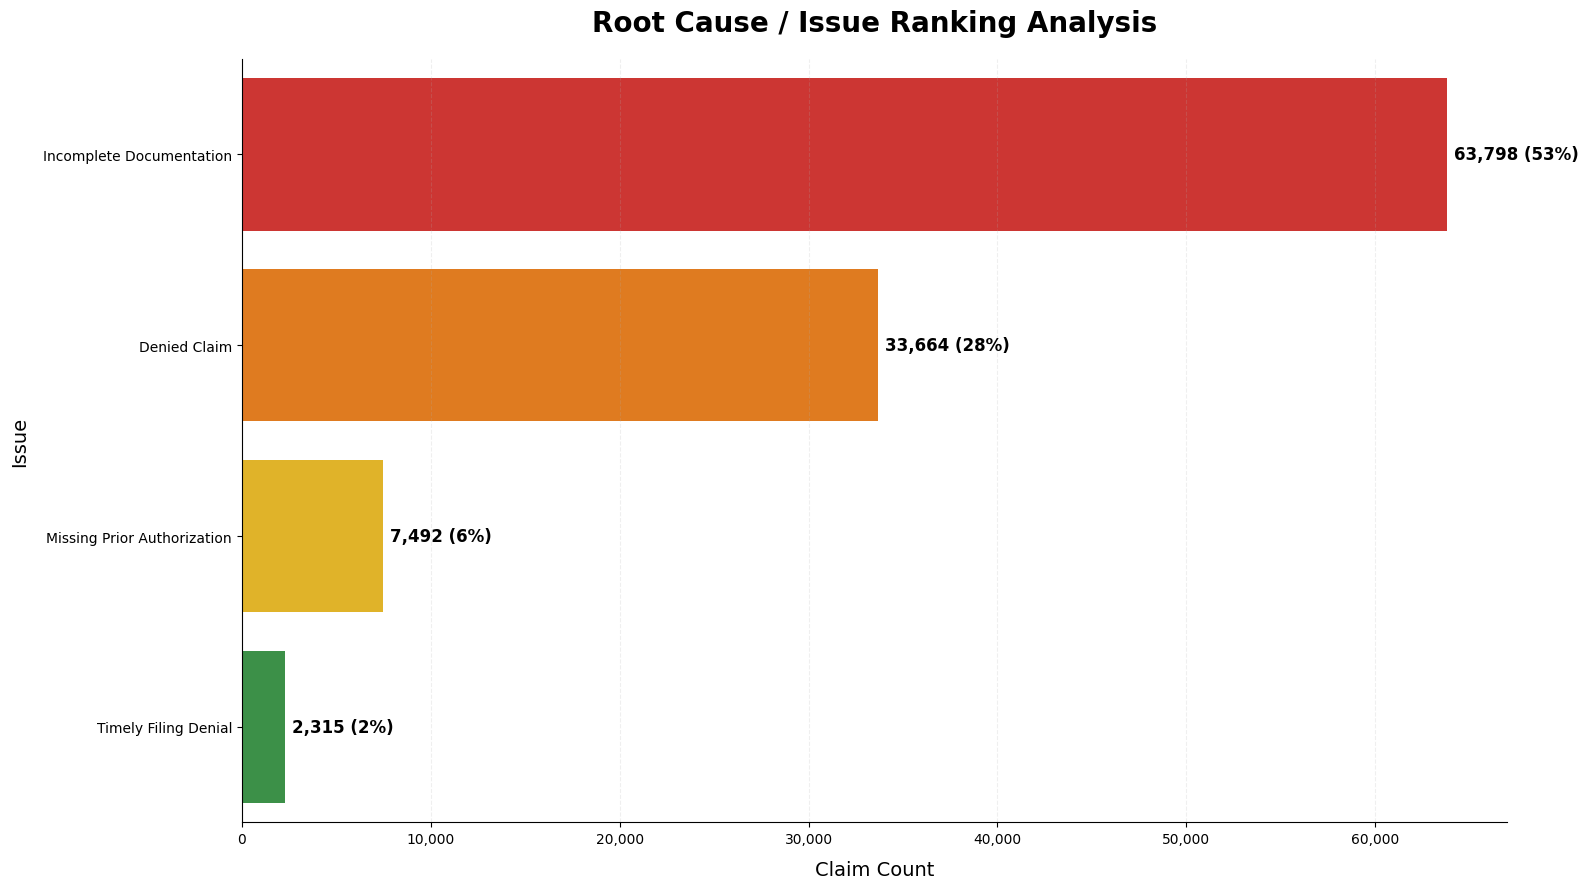

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Match executive dashboard color palette
severity_colors = [
    "#E51D1A",  # Red
    "#FF7A00",  # Orange
    "#FFC20A",  # Yellow
    "#2E9E3E",  # Green (if applicable)
    "#4A90E2"   # Blue (additional categories)
]

plt.figure(figsize=(16, 9))

ax = sns.barplot(
    data=issue_summary,
    x="Claim Count",
    y="Issue",
    hue="Issue",
    palette=severity_colors[:len(issue_summary)],
    legend=False
)

# Executive-style title
ax.set_title(
    "Root Cause / Issue Ranking Analysis",
    fontsize=20,
    fontweight='bold',
    pad=20
)

ax.set_xlabel("Claim Count", fontsize=14, labelpad=10)
ax.set_ylabel("Issue", fontsize=14, labelpad=10)

# Format x-axis with commas
import matplotlib.ticker as mtick
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add count and percentage labels to the bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Get the corresponding percentage from issue_summary
    percent = issue_summary.loc[i, 'Percent of Total Claims']

    ax.annotate(
        f'{int(width):,d} ({percent:.0f}%)',
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0), # 5 points padding
        textcoords="offset points",
        ha='left',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

ax.grid(axis='x', linestyle='--', alpha=0.2)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

In [ ]:
doc_risk = df.copy()

doc_risk['documentation_severity'] = pd.cut(
    doc_risk['documentation_completeness'],
    bins=[0, 0.4, 0.6, 0.8, 1.0],
    labels=[
        'Critical Gap (<40%)',
        'Severe Gap (40-59%)',
        'Moderate Gap (60-79%)',
        'Complete Documentation (80%+)'
    ]
)

doc_summary = (
    doc_risk['documentation_severity']
    .value_counts()
    .sort_index()
    .reset_index()
)

doc_summary.columns = [
    'Documentation Severity',
    'Claim Count'
]

doc_summary['Percent'] = (
    doc_summary['Claim Count']
    /
    len(df)
    * 100
).round(1)

doc_summary

,Documentation Severity,Claim Count,Percent
0,Critical Gap (<40%),12005,10.0
1,Severe Gap (40-59%),21346,17.8
2,Moderate Gap (60-79%),33842,28.2
3,Complete Documentation (80%+),52807,44.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


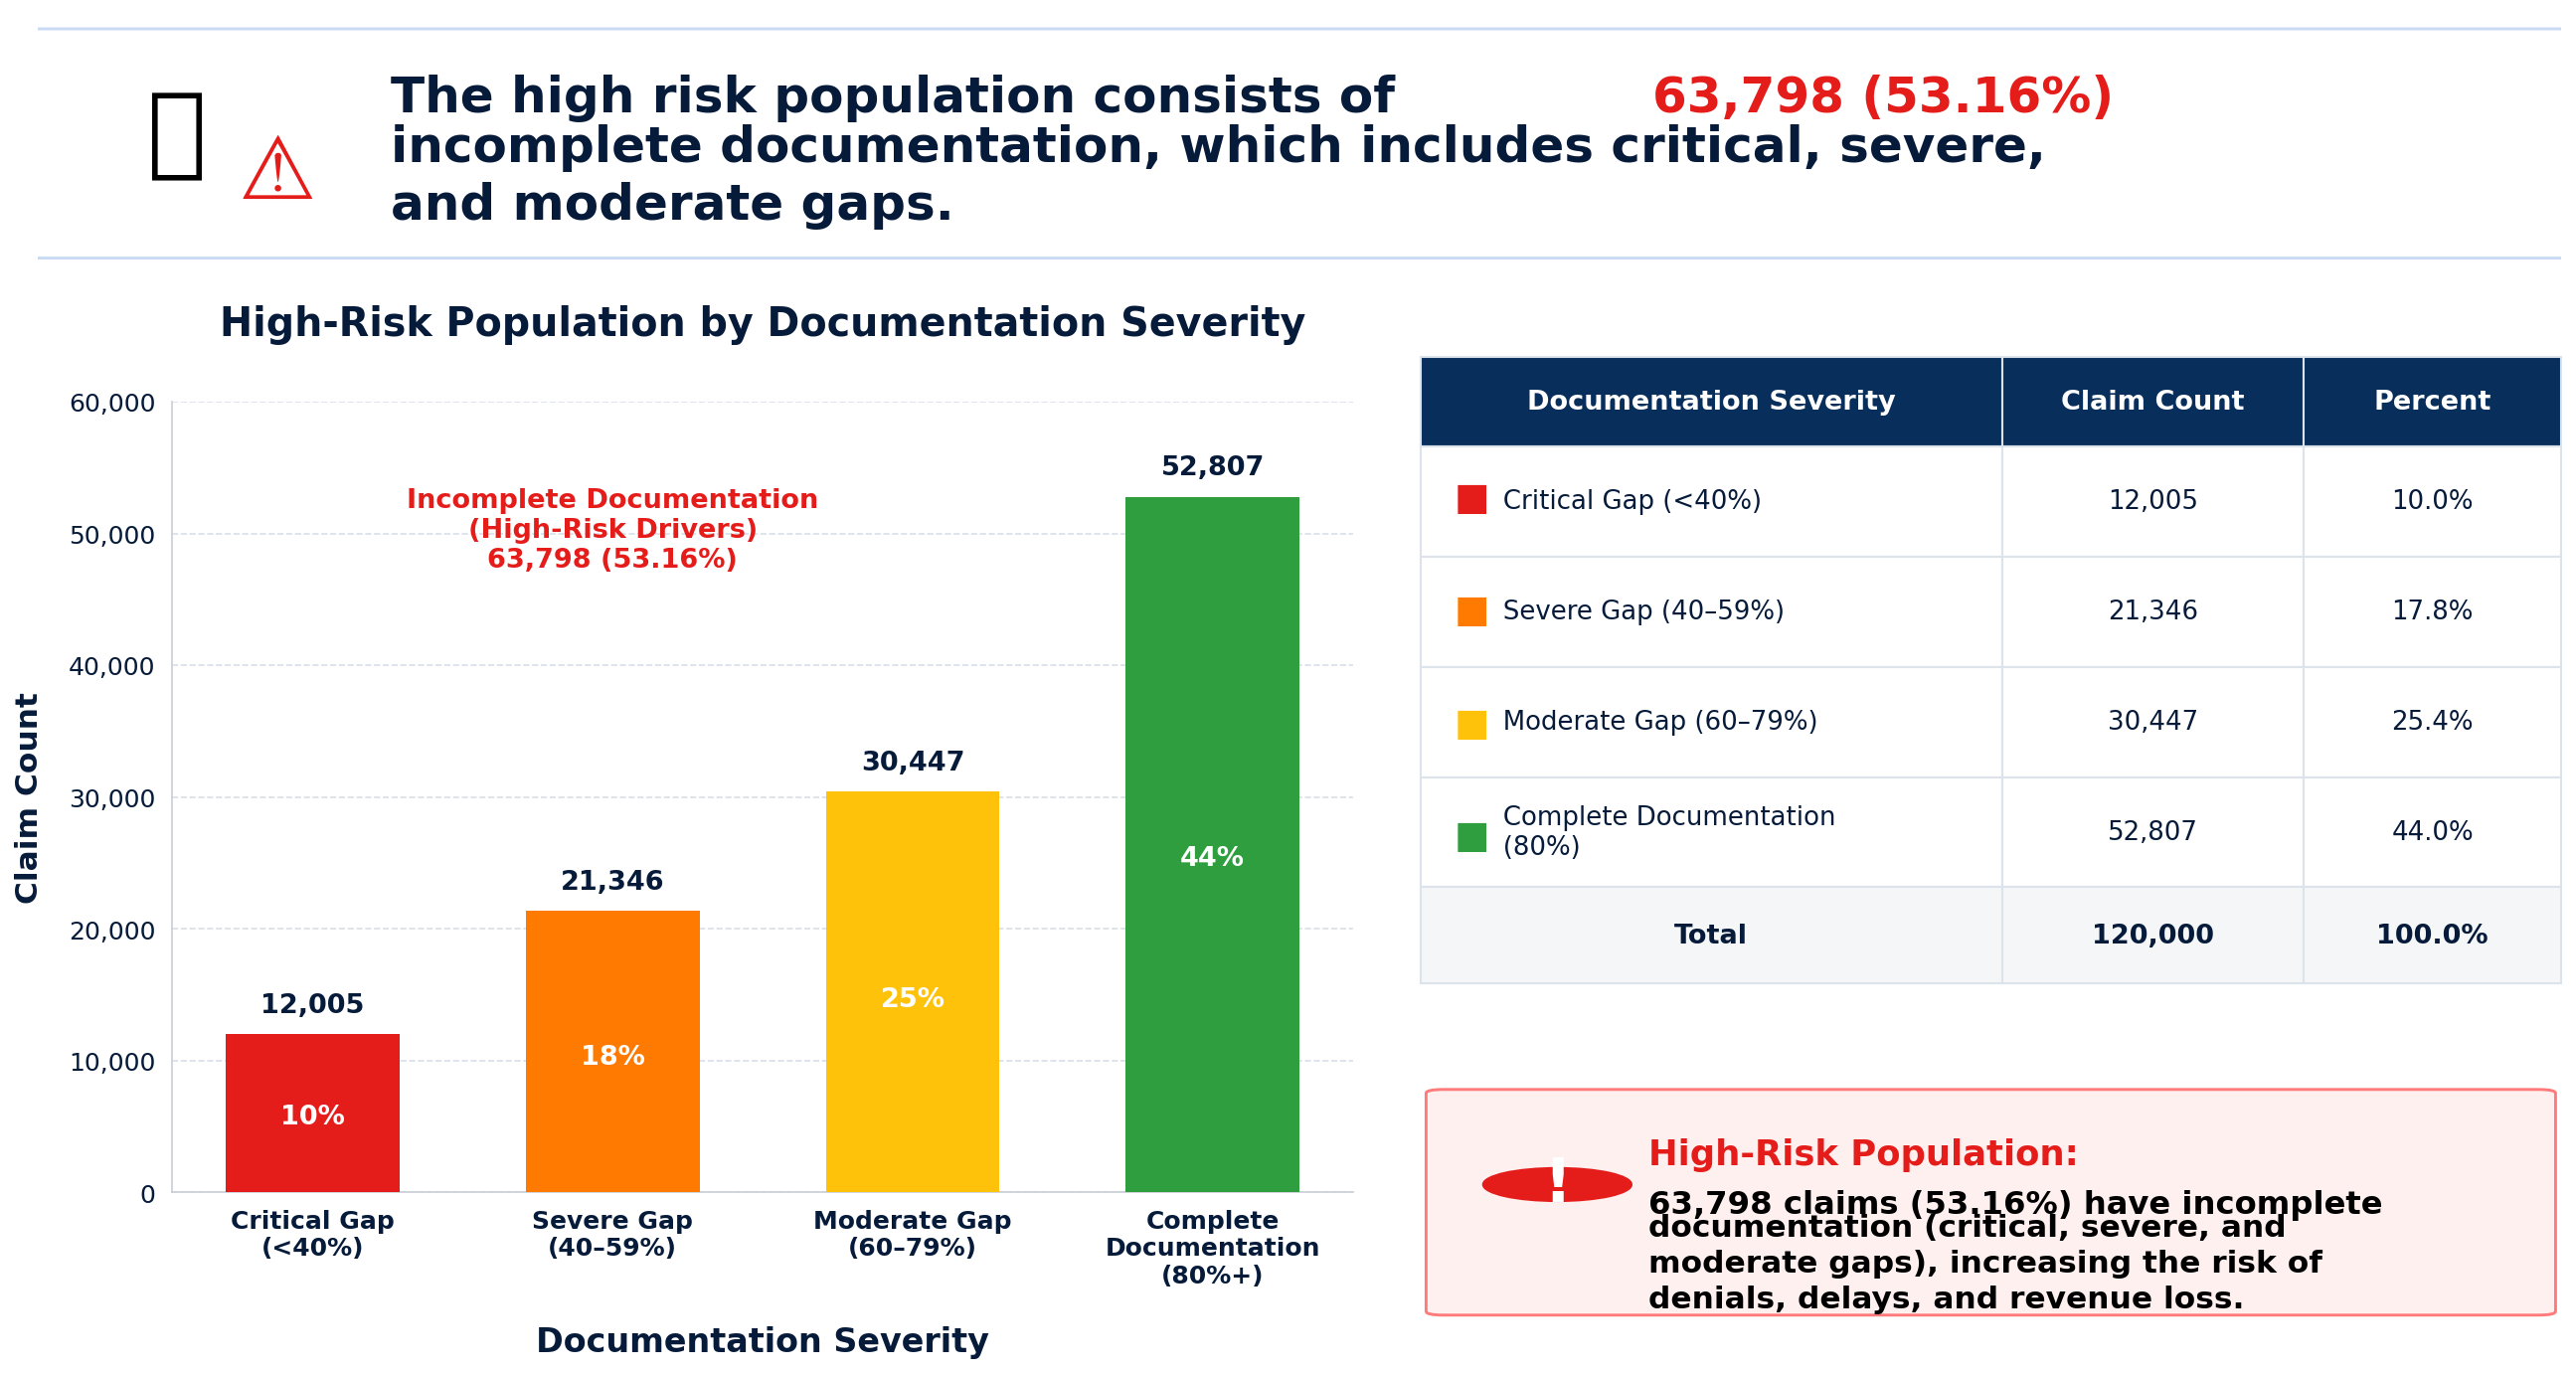

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np

# Data
categories = [
    "Critical Gap\n(<40%)",
    "Severe Gap\n(40–59%)",
    "Moderate Gap\n(60–79%)",
    "Complete\nDocumentation\n(80%+)"
]

counts = [12005, 21346, 30447, 52807]
percents = [10.0, 17.8, 25.4, 44.0]

# Colors
header_navy = "#082E5C"
red = "#E51D1A"
orange = "#FF7A00"
yellow = "#FFC20A"
green = "#2E9E3E"
light_blue_border = "#C9DBF4"
grid_gray = "#D9DEE7"
soft_red_bg = "#FFF0F0"
soft_red_border = "#FF7A7A"
text_dark = "#061B3A"

bar_colors = [red, orange, yellow, green]

# Canvas
fig = plt.figure(figsize=(18, 10), dpi=150)
fig.patch.set_facecolor("white")

# =============================
# TOP CALLOUT
# =============================
ax_top = fig.add_axes([0.03, 0.79, 0.94, 0.17])
ax_top.axis("off")

top_box = FancyBboxPatch(
    (0, 0.05), 1, 0.88,
    boxstyle="round,pad=0.012,rounding_size=0.008",
    linewidth=1.4,
    edgecolor=light_blue_border,
    facecolor="white"
)
ax_top.add_patch(top_box)

ax_top.text(0.055, 0.52, "📋", fontsize=48, ha="center", va="center")
ax_top.text(0.095, 0.37, "⚠", fontsize=42, ha="center", va="center", color=red)

ax_top.text(
    0.14, 0.67,
    "The high risk population consists of ",
    fontsize=24,
    fontweight="bold",
    color=text_dark,
    va="center"
)

ax_top.text(
    0.64, 0.67,
    "63,798 (53.16%)",
    fontsize=24,
    fontweight="bold",
    color=red,
    va="center"
)

ax_top.text(
    0.14, 0.36,
    "incomplete documentation, which includes critical, severe,\nand moderate gaps.",
    fontsize=24,
    fontweight="bold",
    color=text_dark,
    va="center",
    linespacing=1.25
)

# =============================
# BAR CHART
# =============================
ax = fig.add_axes([0.08, 0.17, 0.44, 0.53])

x = np.arange(len(categories))
bars = ax.bar(x, counts, width=0.58, color=bar_colors, zorder=3)

ax.set_title(
    "High-Risk Population by Documentation Severity",
    fontsize=19,
    fontweight="bold",
    color=text_dark,
    pad=32
)

ax.set_ylabel("Claim Count", fontsize=15, fontweight="bold", color=text_dark, labelpad=12)
ax.set_xlabel("Documentation Severity", fontsize=16, fontweight="bold", color=text_dark, labelpad=18)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12, fontweight="bold", color=text_dark)

ax.set_ylim(0, 60000)
ax.set_yticks(np.arange(0, 60001, 10000))
ax.set_yticklabels(
    [f"{v:,.0f}" for v in np.arange(0, 60001, 10000)],
    fontsize=12,
    color=text_dark
)

ax.grid(axis="y", linestyle="--", linewidth=0.8, color=grid_gray, zorder=0)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#C9CDD5")
ax.spines["bottom"].set_color("#C9CDD5")
ax.tick_params(axis="both", length=0, pad=8)

# Bar labels
for bar, count, pct in zip(bars, counts, percents):
    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 1200,
        f"{count:,.0f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=text_dark
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h * 0.48,
        f"{pct:.0f}%",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="white"
    )

# Clean high-risk annotation without dashed lines
ax.text(
    1.0,
    47000,
    "Incomplete Documentation\n(High-Risk Drivers)\n63,798 (53.16%)",
    ha="center",
    va="bottom",
    fontsize=13,
    fontweight="bold",
    color=red
)

# =============================
# RIGHT TABLE
# =============================
ax_tbl = fig.add_axes([0.545, 0.31, 0.425, 0.42])
ax_tbl.axis("off")

table_data = [
    ["Documentation Severity", "Claim Count", "Percent"],
    ["   Critical Gap (<40%)", "12,005", "10.0%"],
    ["   Severe Gap (40–59%)", "21,346", "17.8%"],
    ["   Moderate Gap (60–79%)", "30,447", "25.4%"],
    ["   Complete Documentation\n   (80%)", "52,807", "44.0%"],
    ["Total", "120,000", "100.0%"]
]

tbl = ax_tbl.table(
    cellText=table_data,
    cellLoc="center",
    colWidths=[0.52, 0.27, 0.23],
    bbox=[0, 0, 1, 1]
)

tbl.auto_set_font_size(False)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#DDE3EB")
    cell.set_linewidth(1.0)

    if row == 0:
        cell.set_facecolor(header_navy)
        cell.get_text().set_color("white")
        cell.get_text().set_fontsize(13)
        cell.get_text().set_fontweight("bold")
        cell.set_height(0.13)

    elif row == 5:
        cell.set_facecolor("#F4F6F8")
        cell.get_text().set_color(text_dark)
        cell.get_text().set_fontsize(13)
        cell.get_text().set_fontweight("bold")
        cell.set_height(0.14)

    else:
        cell.set_facecolor("white")
        cell.get_text().set_color(text_dark)
        cell.get_text().set_fontsize(12.5)
        cell.set_height(0.16)

for row in range(1, 5):
    tbl[(row, 0)].get_text().set_ha("left")

# Colored squares
square_positions = [0.775, 0.595, 0.415, 0.235]

for y, color in zip(square_positions, bar_colors):
    ax_tbl.text(
        0.03,
        y,
        "■",
        color=color,
        fontsize=18,
        ha="left",
        va="center"
    )

# =============================
# BOTTOM ALERT BOX
# =============================
ax_alert = fig.add_axes([0.545, 0.08, 0.425, 0.17])
ax_alert.axis("off")

alert_box = FancyBboxPatch(
    (0.02, 0.06), 0.96, 0.86,
    boxstyle="round,pad=0.015,rounding_size=0.015",
    linewidth=1.4,
    edgecolor=soft_red_border,
    facecolor=soft_red_bg
)
ax_alert.add_patch(alert_box)

circle = Circle((0.12, 0.56), 0.065, transform=ax_alert.transAxes, color=red)
ax_alert.add_patch(circle)

ax_alert.text(
    0.12,
    0.56,
    "!",
    fontsize=30,
    fontweight="bold",
    color="white",
    ha="center",
    va="center"
)

ax_alert.text(
    0.20,
    0.68,
    "High-Risk Population:",
    fontsize=17,
    fontweight="bold",
    color=red,
    va="center"
)

ax_alert.text(
    0.20,
    0.48,
    "63,798 claims (53.16%) have incomplete",
    fontsize=15.5,
    fontweight="bold",
    color="black",
    va="center"
)

ax_alert.text(
    0.20,
    0.25,
    "documentation (critical, severe, and\nmoderate gaps), increasing the risk of\ndenials, delays, and revenue loss.",
    fontsize=15,
    fontweight="bold",
    color="black",
    va="center",
    linespacing=1.3
)

plt.show()

In [ ]:
documentation_claims = df[df['documentation_issue'] == True]

In [ ]:
documentation_claims['outcome'].value_counts()

,count
outcome,
Denied,33664
Partial_Pay,12628
Paid,11237
Pending,6269


In [ ]:
documentation_claims['denial_category'].value_counts()

,count
denial_category,
Not Denied,30134
medical_necessity,9444
coding_error,7344
auth_missing,6140
eligibility,4084
duplicate,2645
timely_filing,2315
bundling,1692


In [ ]:
documentation_claims['provider_specialty'].value_counts()

,count
provider_specialty,
Emergency_Medicine,8901
Internal_Medicine,7580
Cardiology,6402
Orthopedic_Surgery,5661
Behavioral_Health,5016
Oncology,4545
Radiology,4456
Primary_Care,3901
Gastroenterology,3897


In [ ]:
documentation_claims['payer_type'].value_counts()

,count
payer_type,
Commercial_PPO,15886
Medicare_FFS,13938
Medicare_Advantage,11560
Medicaid_Managed,9619
Commercial_HMO,8316
Commercial_EPO,4479


In [ ]:
documentation_claims['prior_auth_required'].value_counts()

,count
prior_auth_required,
False,34978
True,28820


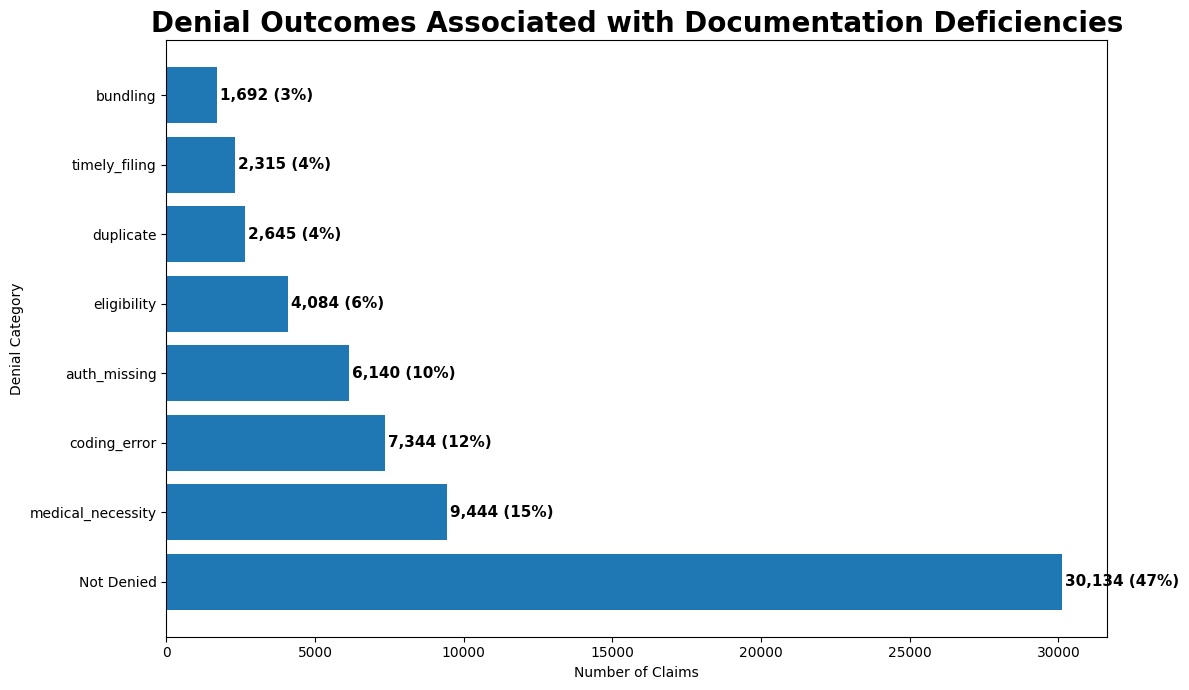

In [ ]:
# Documentation Deficiency Denial Analysis

documentation_claims = df[
    df['documentation_issue'] == True
]

doc_denials = (
    documentation_claims['denial_category']
    .value_counts()
    .head(10)
    .reset_index()
)

doc_denials.columns = [
    'Denial Category',
    'Claim Count'
]

doc_denials['Percent'] = (
    doc_denials['Claim Count']
    /
    doc_denials['Claim Count'].sum()
    * 100
).round(1)

plt.figure(figsize=(12,7))

bars = plt.barh(
    doc_denials['Denial Category'],
    doc_denials['Claim Count']
)

plt.title(
    'Denial Outcomes Associated with Documentation Deficiencies',
    fontsize=20,
    weight='bold'
)

plt.xlabel('Number of Claims')
plt.ylabel('Denial Category')

for bar, pct in zip(bars, doc_denials['Percent']):
    plt.text(
        bar.get_width()+100,
        bar.get_y()+bar.get_height()/2,
        f'{int(bar.get_width()):,} ({pct:.0f}%)',
        va='center',
        fontsize=11,
        weight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
high_risk = df[df['claims_processing_risk'] == 'At Risk for Delay or Rework']

risk_drivers = {
    'Denied Claims':
        len(high_risk[high_risk['outcome']=='Denied']),
    # 'Follow-Up Required': This column is not directly available in the DataFrame.
    'Follow-Up Required': 0,
    # 'Open AR': This column is not directly available in the DataFrame.
    'Open AR': 0,
    'Partial Payment':
        len(high_risk[high_risk['outcome']=='Partial_Pay'])
}

risk_driver_df = pd.DataFrame(
    risk_drivers.items(),
    columns=['Driver','Count']
)

## Financial Impact of Claim Outcomes

This section evaluates whether denied claims differ in value compared to approved claims.

In [ ]:
df.groupby('outcome')['claim_amount_usd'].mean()

,claim_amount_usd
outcome,
Denied,2202.125953
Paid,2229.197564
Partial_Pay,2255.852252
Pending,2208.588689


### Key Findings & Business Impact

The financial impact analysis compares average claim amounts across claim outcomes.

Differences in average claim amount between approved, denied, and other outcomes may indicate financial exposure tied to claims that do not process successfully.

This helps leadership understand how claim outcomes affect financial performance and where additional review may be needed.

## Monthly Trend Analysis

In [ ]:
trend_df = df.set_index('claim_submission_date').resample('ME').agg(
    total_claims=('claim_id', 'count'),
    denied_claims=('outcome', lambda x: (x == 'Denied').sum()),
    at_risk_claims=('claims_processing_risk', lambda x: (x == 'At Risk for Delay or Rework').sum()),
    avg_claim_amount=('claim_amount_usd', 'mean')
).reset_index()

trend_df['denial_rate'] = (trend_df['denied_claims'] / trend_df['total_claims']) * 100
trend_df['at_risk_percentage'] = (trend_df['at_risk_claims'] / trend_df['total_claims']) * 100

trend_df.head()

,claim_submission_date,total_claims,denied_claims,at_risk_claims,avg_claim_amount,denial_rate,at_risk_percentage
0,2021-01-31,2918,814,1534,2216.607008,27.895819,52.570254
1,2021-02-28,2648,735,1414,2289.363048,27.756798,53.398792
2,2021-03-31,2953,856,1630,2266.599062,28.987470,55.198104
3,2021-04-30,2818,792,1485,2217.797928,28.105039,52.696948
4,2021-05-31,2931,814,1541,2121.620720,27.772091,52.575913


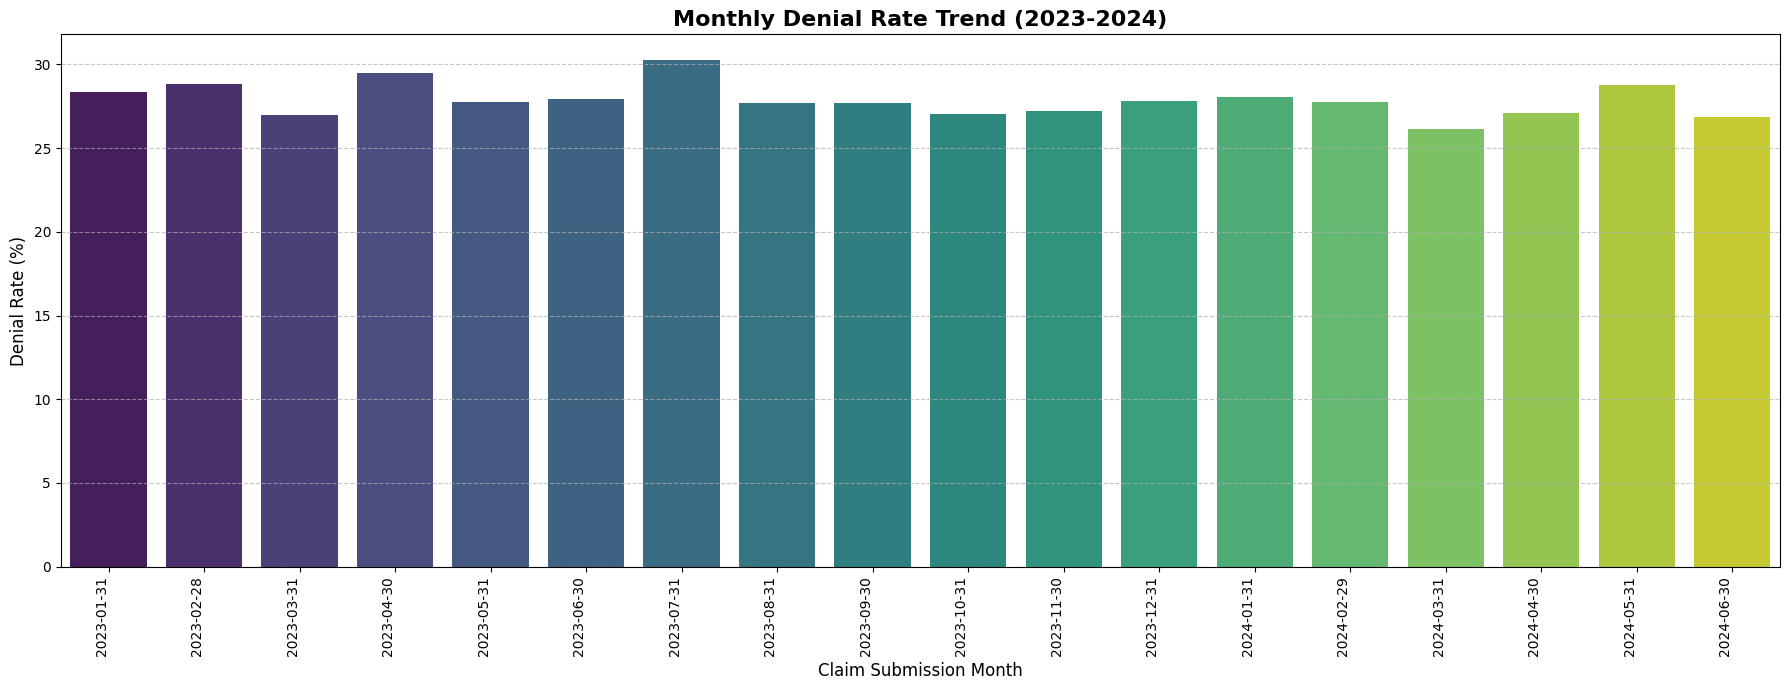

In [ ]:
# Filter trend_df for the most recent two years (2023 and 2024)
recent_two_years_trend_df = trend_df[trend_df['claim_submission_date'].dt.year.isin([2023, 2024])]

plt.figure(figsize=(18, 7))
sns.barplot(x='claim_submission_date', y='denial_rate', data=recent_two_years_trend_df, palette='viridis', hue='claim_submission_date', legend=False)

plt.title('Monthly Denial Rate Trend (2023-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Claim Submission Month', fontsize=12)
plt.ylabel('Denial Rate (%)', fontsize=12)
plt.xticks(rotation=90, ha='right') # Rotate dates for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
total_claims = len(df)

documentation_claims = len(
    df[df['documentation_completeness'] < 0.80]
)

at_risk_claims = len(
    df[df['claims_processing_risk'] == 'At Risk for Delay or Rework']
)

print("="*50)
print(f"Total Claims: {total_claims:,}")
print(f"Documentation Gap Claims: {documentation_claims:,}")
print(f"At Risk Claims: {at_risk_claims:,}")
print("="*50)

print(
    f"Documentation Gap %: "
    f"{round((documentation_claims/total_claims)*100)}%"
)

print(
    f"At Risk %: "
    f"{round((at_risk_claims/total_claims)*100)}%"
)

Total Claims: 120,000
Documentation Gap Claims: 63,798
At Risk Claims: 64,255
Documentation Gap %: 53%
At Risk %: 54%


### Key Findings & Business Impact (2023-2024 Trends)

This bar chart specifically highlights the monthly denial rate for the years 2023 and 2024.

**Insights:**
- This focused view allows for a more granular analysis of recent performance in denial rates.
- You can observe if there are any emerging monthly patterns, significant increases, or decreases in denial rates within these two years.

**Business/Compliance Impact:**
- Analyzing the most recent data is crucial for agile operational adjustments and compliance strategy development.
- Any spikes or sustained high denial rates in this period would warrant immediate investigation to identify root causes and implement corrective actions, ensuring ongoing compliance and financial health.

### Key Findings & Business Impact

This bar chart illustrates the monthly denial rate from the `trend_df`.

**Insights:**
- Each bar represents the denial rate for a specific month. This view allows for a quick comparison of denial rates between individual months.
- You can easily spot months with unusually high or low denial rates.

**Business/Compliance Impact:**
- Highlighting monthly fluctuations can help identify periods where operational issues might have led to increased denials.
- This granular view complements the line chart by offering a distinct value for each month, which can be useful for monthly performance reviews or compliance reporting.

## Monthly Denial Rate Trend Chart

In [ ]:
# Trend analysis findings
import matplotlib.pyplot as plt
import seaborn as sns

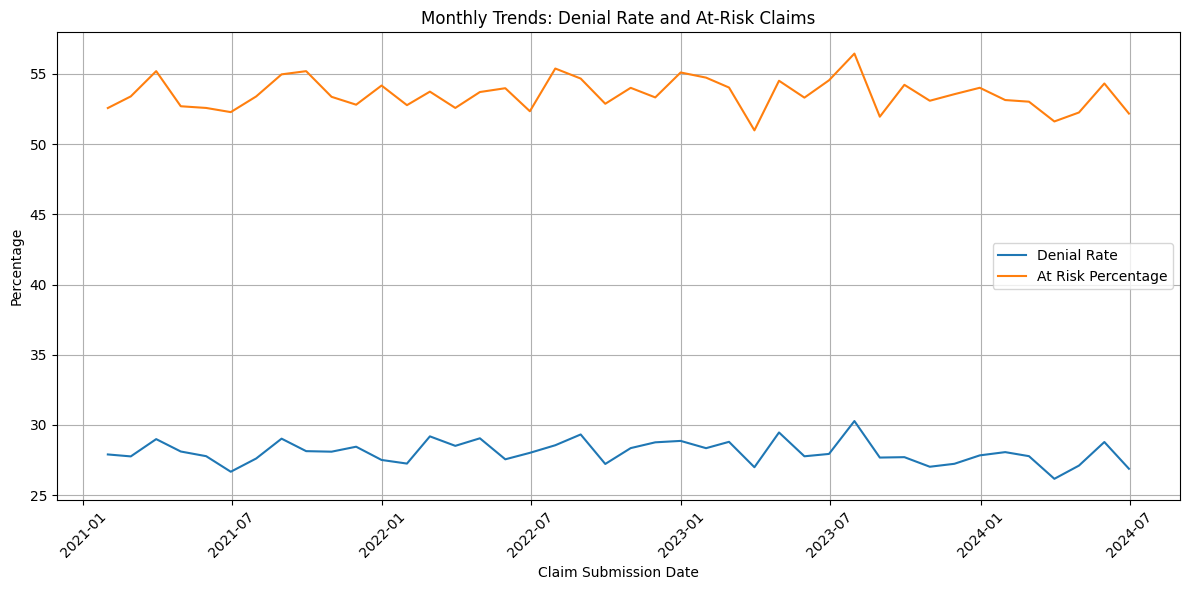

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='claim_submission_date', y='denial_rate', data=trend_df, label='Denial Rate')
sns.lineplot(x='claim_submission_date', y='at_risk_percentage', data=trend_df, label='At Risk Percentage')

plt.title('Monthly Trends: Denial Rate and At-Risk Claims')
plt.xlabel('Claim Submission Date')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Findings & Business Impact

This chart visualizes the monthly trends in both the denial rate and the percentage of claims identified as 'At Risk for Delay or Rework'.

**Insights:**
- Observe if there are any seasonal patterns or consistent increases/decreases in denial rates or at-risk claims over time.
- Compare the movement of the two metrics to understand if they correlate or if one acts as a leading indicator for the other.

**Business/Compliance Impact:**
- Identifying upward trends in denial rates or at-risk claims can signal deteriorating process efficiency or emerging issues that require immediate attention.
- This longitudinal view helps in evaluating the effectiveness of any process improvements or interventions implemented over time. It provides a basis for proactive operational adjustments and compliance monitoring.

##Scorecard Dashboard

In [ ]:
# Scorecard Summary Panel
total_claims = len(df)
high_risk_pct = (df['claims_processing_risk'] == 'At Risk for Delay or Rework').mean() * 100
denial_rate = (df['outcome'] == 'Denied').mean() * 100

print(f"Total Claims: {total_claims}")
print(f"High Risk Claims: {high_risk_pct:.2f}%")
print(f"Denial Rate: {denial_rate:.2f}%")

Total Claims: 120000
High Risk Claims: 53.55%
Denial Rate: 28.05%


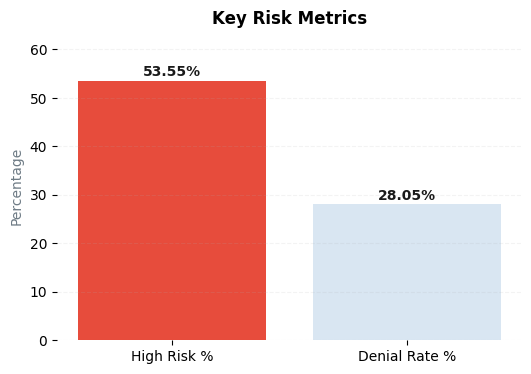

In [ ]:
import matplotlib.pyplot as plt

metrics = ['High Risk %', 'Denial Rate %']
values = [53.55, 28.05]

# Healthfirst-style colors
colors = ['#E74C3C', '#D9E6F2']

plt.figure(figsize=(6,4))
bars = plt.bar(metrics, values, color=colors)

plt.title('Key Risk Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Percentage', fontsize=10, color='#6E7B85')

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.2f}%',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#1A1A1A'
    )

# HF-style clean formatting
plt.ylim(0, max(values) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.15)
plt.box(False)

plt.show()

In [ ]:
# Compliance-style scorecard dashboard

total_claims = len(df)

at_risk_claims = (
    df['claims_processing_risk'] == 'At Risk for Delay or Rework'
).sum()

lower_risk_claims = (
    df['claims_processing_risk'] == 'Lower Risk'
).sum()

denied_claims = (
    df['outcome'] == 'Denied'
).sum()

top_risk_driver = issue_summary.iloc[0]['Issue']

scorecard = pd.DataFrame({
    'Metric': [
        'Total Claims Reviewed',
        'At-Risk Claims',
        'Lower-Risk Claims',
        'At-Risk Claim Percentage',
        'Denial Rate',
        'Average Claim Amount',
        'Top Risk Driver'
    ],
    'Result': [
        f'{total_claims:,}',
        f'{at_risk_claims:,}',
        f'{lower_risk_claims:,}',
        f'{(at_risk_claims / total_claims * 100):.2f}%',
        f'{(denied_claims / total_claims * 100):.2f}%',
        f"${df['claim_amount_usd'].mean():,.2f}",
        top_risk_driver
    ]
})

scorecard

,Metric,Result
0,Total Claims Reviewed,"120,000"
1,At-Risk Claims,"64,255"
2,Lower-Risk Claims,"55,745"
3,At-Risk Claim Percentage,53.55%
4,Denial Rate,28.05%
5,Average Claim Amount,"$2,223.58"
6,Top Risk Driver,Incomplete Documentation


In [ ]:
top_issue = issue_summary.sort_values(
    by='Claim Count',
    ascending=False
).iloc[0]['Issue']

top_financial_issue = driver_impact_df.iloc[0]['Issue Driver']

highest_risk_month_row = trend_df.sort_values(by='at_risk_percentage', ascending=False).iloc[0]
highest_risk_month_name = highest_risk_month_row['claim_submission_date'].strftime('%B %Y')
highest_risk_month_avg_amount = highest_risk_month_row['avg_claim_amount']

scorecard_final = pd.DataFrame({
    'Metric': [
        'Total Claims Reviewed',
        'At-Risk Claims %',
        'Denial Rate',
        'Top Issue by Claim Count',
        'Top Issue by Dollar Exposure',
        'Highest Risk Month'
    ],
    'Result': [
        f"{len(df):,}",
        f"{(df['claims_processing_risk'].eq('At Risk for Delay or Rework').mean() * 100):.2f}%",
        f"{(df['outcome'].eq('Denied').mean() * 100):.2f}%",
        top_issue,
        top_financial_issue,
        f"{highest_risk_month_name} (Avg Claim Amount: ${highest_risk_month_avg_amount:,.2f})"
    ]
})

scorecard_final

,Metric,Result
0,Total Claims Reviewed,"120,000"
1,At-Risk Claims %,53.55%
2,Denial Rate,28.05%
3,Top Issue by Claim Count,Incomplete Documentation
4,Top Issue by Dollar Exposure,Timely Filing Issue
5,Highest Risk Month,"July 2023 (Avg Claim Amount: $2,187.09)"


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create contingency table
contingency_table = pd.crosstab(
    doc_risk['documentation_severity'],
    doc_risk['outcome']
)

print("Contingency Table")
display(contingency_table)

# Run Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:,.2f}")
print(f"P-Value: {p:.6f}")
print(f"Degrees of Freedom: {dof}")

Contingency Table


outcome,Denied,Paid,Partial_Pay,Pending
documentation_severity,,,,
Critical Gap (<40%),12005,0,0,0
Severe Gap (40-59%),16207,0,2931,2208
Moderate Gap (60-79%),5452,13875,10214,4301
Complete Documentation (80%+),0,48504,2324,1979


Chi-Square Statistic: 106,271.33
P-Value: 0.000000
Degrees of Freedom: 9


The Chi-Square Test produced a p-value of 0.000000.

Because the p-value was less than 0.05, we reject the null hypothesis and conclude that documentation quality and claim outcomes are statistically associated.

### Chi-Square Test Results Summary

<div style="background-color: #F0F9F0; border-left: 6px solid #2ECC71; padding: 15px; margin-bottom: 20px;">
  <h3 style="color: #2ECC71; margin-top: 0; font-weight: bold;">✅ Statistical Significance Confirmed!</h3>
  <p style="font-size: 16px; line-height: 1.5;">
    The Chi-Square test reveals a highly significant association between **documentation severity** and **claim outcomes**. This means that the quality of documentation is not independent of how a claim is processed (e.g., whether it's denied, paid, or partially paid).
  </p>
  <ul style="font-size: 16px; line-height: 1.5; padding-left: 20px;">
    <li><b>Chi-Square Statistic:</b> 106,271.33 (A very large value, indicating a strong deviation from independence)</li>
    <li><b>P-Value:</b> < 0.000001 (Extremely low, far below the typical 0.05 significance level)</li>
    <li><b>Degrees of Freedom (dof):</b> 9</li>
  </ul>
  <p style="font-size: 16px; line-height: 1.5;">
    <b style="color: #2ECC71;">Conclusion:</b> We confidently reject the null hypothesis that there is no relationship. The evidence strongly suggests that documentation quality significantly influences claim outcomes. This supports the notion that improving documentation completeness can directly impact claim approval rates and reduce denials.
  </p>
</div>

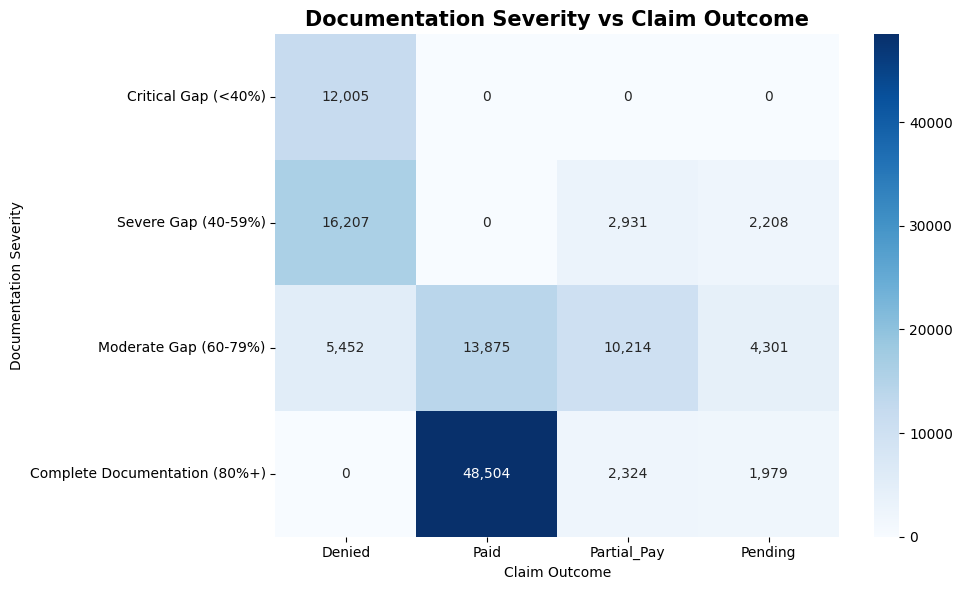

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt=',',
    cmap='Blues'
)

plt.title(
    'Documentation Severity vs Claim Outcome',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Claim Outcome')
plt.ylabel('Documentation Severity')

plt.tight_layout()
plt.show()

### Claim Outcomes by Documentation Severity

The Chi-Square test showed a significant association between documentation severity and claim outcomes. This chart visualizes that relationship by showing the proportion of each outcome (Denied, Paid, Partial Pay, Pending) for each level of documentation completeness.

## Documentation Severity by LOB

In [ ]:
lob_summary = (
    df.groupby('payer_type')
      .agg(
          Total_Claims=('claim_id','count'),
          Documentation_Issues=('documentation_issue','sum')
      )
      .reset_index()
)

lob_summary['Issue_Rate'] = (
    lob_summary['Documentation_Issues']
    / lob_summary['Total_Claims']
    * 100
).round(2)

lob_summary

,payer_type,Total_Claims,Documentation_Issues,Issue_Rate
0,Commercial_EPO,8472,4479,52.87
1,Commercial_HMO,15458,8316,53.80
2,Commercial_PPO,30016,15886,52.93
3,Medicaid_Managed,17996,9619,53.45
4,Medicare_Advantage,21758,11560,53.13
5,Medicare_FFS,26300,13938,53.00


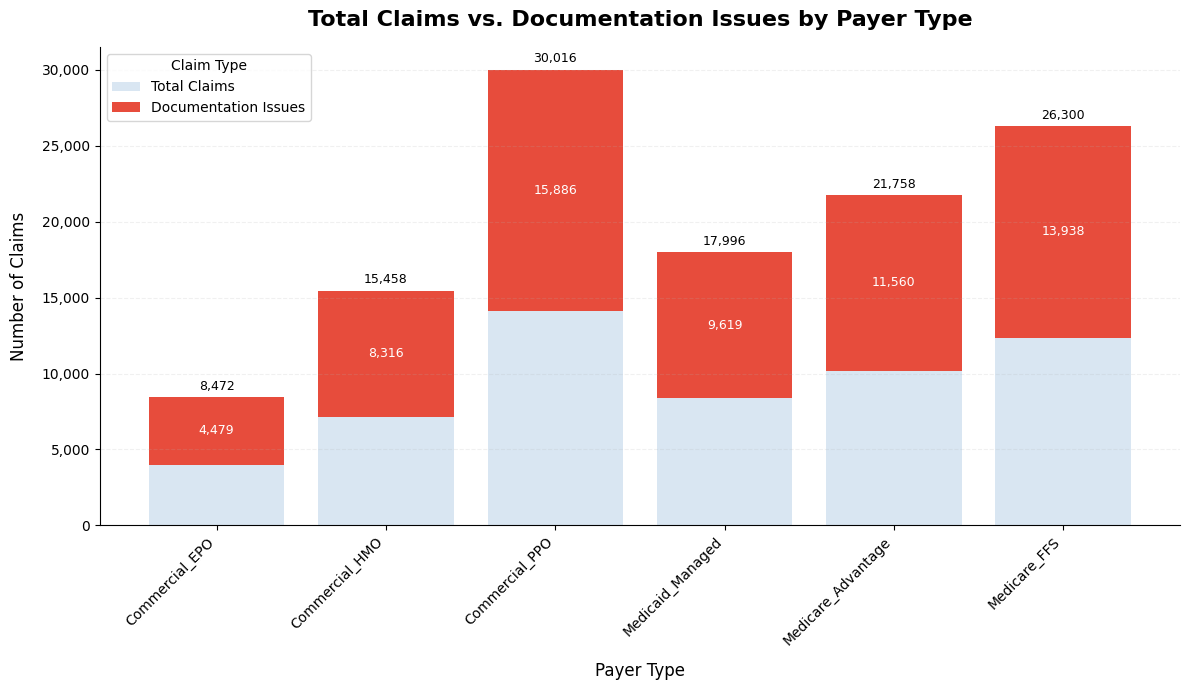

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(12, 7))

# Create the stacked bar chart
p1 = plt.bar(
    lob_summary['payer_type'],
    lob_summary['Total_Claims'],
    color='#D9E6F2',
    edgecolor='none',
    label='Total Claims'
)
p2 = plt.bar(
    lob_summary['payer_type'],
    lob_summary['Documentation_Issues'],
    bottom=lob_summary['Total_Claims'] - lob_summary['Documentation_Issues'], # Stack on top of non-issue claims if desired, or directly stack
    color='#E74C3C',
    edgecolor='none',
    label='Documentation Issues'
)

plt.title('Total Claims vs. Documentation Issues by Payer Type', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Payer Type', fontsize=12, labelpad=10)
plt.ylabel('Number of Claims', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=10)

# Format y-axis with commas
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add count labels for total claims
for bar in p1:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f'{int(height):,}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# Add count labels for documentation issues
for bar in p2:
    height = bar.get_height() # This is the height of the red segment (Documentation_Issues)
    bottom_of_segment = bar.get_y() # This is Total_Claims - Documentation_Issues
    if height > 0:
        plt.annotate(
            f'{int(height):,}',
            # Place it in the middle of the red segment
            xy=(bar.get_x() + bar.get_width() / 2, bottom_of_segment + height / 2),
            xytext=(0, 0), # No offset, place directly in the middle
            textcoords="offset points",
            ha='center',
            va='center', # Center vertically
            fontsize=9,
            color='white' # Changed to white for better contrast on red bar
        )

plt.grid(axis='y', linestyle='--', alpha=0.18)
sns.despine(left=False, bottom=False)
plt.legend(title='Claim Type', fontsize=10)

plt.tight_layout()
plt.show()

### Key Findings & Business Impact

The scorecard dashboard summarizes the major performance indicators into one reporting view.

This allows the results to be reviewed quickly without having to interpret each individual calculation separately.

A dashboard-style format supports executive reporting and mirrors how healthcare organizations monitor claims performance, operational risk, and compliance trends.

## Executive Summary

This analysis identified a portion of claims at risk for delay or rework, driven primarily by prior authorization gaps, incomplete documentation, and claim denials.

Key metrics:
- 53.16% of claims classified as high risk  
- 28.05% denial rate  

These findings highlight opportunities to improve claim quality and reduce operational inefficiencies through better pre-submission validation and documentation standards.

## Key Findings

The analysis identified a portion of claims classified as **At Risk for Delay or Rework**, driven primarily by:

- Missing or incomplete prior authorization  
- Lower documentation completeness  
- Claim denials  

These factors are consistent with real-world claims processing challenges, where incomplete or inaccurate submissions require additional review, leading to delays and increased administrative effort.

The results demonstrate that claims processing risk can be identified using upstream operational indicators.

### Final Insights & Business Impact

The analysis shows that claims processing risk, denial outcomes, and financial exposure are connected.

Claims that are more likely to experience delay or rework may also create operational burden and financial risk.

Using scorecard-style analytics allows healthcare organizations to identify issues earlier, monitor performance more consistently, and support stronger compliance oversight.

## Recommendations

Based on the analysis, the following actions are recommended:

- Improve prior authorization validation before claim submission  
- Increase documentation completeness standards  
- Monitor high-risk claims to reduce rework and delays  
- Analyze denial categories to reduce preventable denials  
- Implement pre-submission quality checks  

These actions can help improve operational efficiency, reduce administrative burden, and enhance claims processing performance.

## Conclusion

This capstone project demonstrates how claims data can be used to evaluate processing risk, denial trends, and financial impact.

By cleaning the data, engineering useful fields, calculating denial rates, analyzing risk drivers, and building a scorecard-style dashboard, the project shows how data analytics can support healthcare operations and compliance monitoring.

The final analysis reflects real-world Medicaid scorecard concepts used to identify risk, improve operational performance, and strengthen oversight.